## Impact Of Covid-19 pandemic on Nigeria Economic Sector

              By Awolusi Oluwabukola

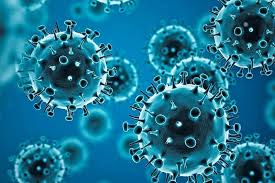

 Table of Contents
1. Introduction
2. Data Wrangling
3. Exploratory Data Analysis
4. Conclusions and Recommendations
5. References

# 1. Introduction

The COVID-19 pandemic has severely impacted Nigeria, affecting its economy, healthcare system, and population. The early part of the COVID-19 crisis ushered in Nigeria deepest recession since the 1980s, with services and industry hit especially hard. The COVID-19 pandemic and aftermath have had a huge effect on Nigeria’s socioeconomic growth, affecting many parts of the country’s economy and society. One of the biggest problems has been the disruption of the economy, which has caused people to lose their jobs and see big differences in their incomes. Due to lockdowns, many companies, especially small and medium-sized ones, had to close or cut back on their hours, which hurt people’s ability to make a living and made poverty worse. This analysis aims to provide insights into the spread of COVID-19 in Nigeria, identifying high-risk states, and assessing the impact of lockdown phases on confirmed cases.

In this project, we:
- Analyze the spread of COVID-19 across Nigeria using NCDC and Johns Hopkins data
- Identify high-risk states based on confirmed cases and death counts
- Analyze the impact of the pandemic on Nigeria’s real GDP from 2014 to 2020
- Determine state-level death rates and community infection rates
- Assess the relationship between population density, health infrastructure, and confirmed cases
- Evaluate the impact of lockdown phases on daily infection trends

 1.1 Dataset Description

This project uses multiple datasets to analyze COVID-19 trends and economic impact in Nigeria.

 1. NCDC COVID-19 Data
- Source: Nigeria Centre for Disease Control
- Time Period: February 2020 – December 2021
- Content: Daily state-level records of confirmed cases, deaths, and recovered cases
- Format: CSV file loaded using `pd.read_csv()`
- Key Columns: `Date`, `State`, `Confirmed_Cases`, `Deaths`, `Recovered`

 2. Johns Hopkins CSSE COVID-19 Data
- Source: [Johns Hopkins University CSSE Repository](https://github.com/CSSEGISandData/COVID-19)
- Time Period: January 2020 – 2023
- Content: Global time series of confirmed cases, deaths, and recoveries
- Use: Filtered to extract Nigeria’s national-level data
- Key Columns: `Country/Region`, `Date`, `Confirmed`, `Deaths`, `Recovered`


 3. External Datasets
| Dataset | Source | Description | Use Case |
| --- | --- | --- | --- |
| **COVID-19 Vulnerability Index** | External health agencies | State-level CCVI scores measuring community vulnerability | Correlate vulnerability with case counts |
| **Budget Data** | Federal Ministry of Finance | Annual state budget allocations | Assess funding vs health outcomes |
| **Real GDP Data** | National Bureau of Statistics | Quarterly real GDP for Nigeria, 2014–2020 | Measure economic impact of pandemic |
| **Health System Metrics** | WHO / NCDC | IHR capacity scores, healthcare access indicators | Evaluate state-level preparedness |

 1.2 Importing Dependencies
In this project, we import `numpy` and `pandas` for data wrangling, `matplotlib` and `seaborn` for plotting.

In [3]:
# importing data analysis libraries
import numpy as np
import pandas as pd

# Web scraping libraries
import requests
import urllib.request
import csv
from bs4 import BeautifulSoup

# importing visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Configuration
sns.set_style("darkgrid")
%matplotlib inline
plt.style.use('fivethirtyeight')  

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

 1.3 Loading the dataset

# Scrapping data from ncdc using pd.read_csv


In [17]:
# the provided url https://covid19.ncdc.gov.ng/ was not used as it was experiencing network downtime

ncdc= pd.read_csv(r'C:\Users\DELL\Downloads\covidnig.csv')

# John Hopkins Data Repository

In [9]:
import ssl

# Set the path to the CA certificates bundle
ssl._create_default_https_context = ssl._create_unverified_context

In [10]:
daily_confirmed = pd.read_csv(r'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_confirmed_global.csv')

In [11]:
daily_recovered = pd.read_csv(r'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_recovered_global.csv')

In [12]:
daily_death = pd.read_csv(r'https://raw.githubusercontent.com/CSSEGISandData/COVID-19/master/csse_covid_19_data/csse_covid_19_time_series/time_series_covid19_deaths_global.csv')

# Saving the external data to a data frame

In [13]:
covid_ext = pd.read_csv(r'C:\Users\DELL\Downloads\covid_external.csv')

In [14]:
Budget = pd.read_csv(r'C:\Users\DELL\Downloads\Budget data.csv')

In [15]:
Real_gdp = pd.read_csv(r'C:\Users\DELL\Downloads\RealGDP.csv')

# Obtaining basic information from the dataset using head() and info()

In [18]:
ncdc.head()

,States Affected,No. of Cases (Lab Confirmed),No. of Cases (on admission),No. Discharged,No. of Deaths
0,Lagos,"26,708","2,435","24,037",236
1,FCT,"9,627","2,840","6,694",93
2,Kaduna,"4,504",579,"3,877",48
3,Plateau,"4,262",280,"3,948",34
4,Oyo,"3,788",368,"3,374",46


 2. # Data Wrangling

In this section, we clean and prepare the raw data for analysis. We check for errors, inconsistencies, missing values, and duplicate entries to ensure the dataset is accurate and reliable.

We will answer the following questions:

1. Are there missing values in the dataset? If so, what is their extent and data type?
2. Are there duplicate entries in the dataset?
3. Are there outliers that could affect the analysis results?

In [19]:
# summary of the dataset
ncdc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   States Affected               37 non-null     object
 1   No. of Cases (Lab Confirmed)  37 non-null     object
 2   No. of Cases (on admission)   37 non-null     object
 3   No. Discharged                37 non-null     object
 4   No. of Deaths                 37 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 1.6+ KB


1. Shape: The dataset contains 37 rows and 5 columns. Each row represents one of Nigeria's 36 states + FCT.
2. Missing Values: All columns have 37 non-null entries. No missing values detected.
3. Data Types: 
   - `No. of Deaths` is correctly stored as `int64`
   - `No. of Cases (Lab Confirmed)`, `No. of Cases (on admission)`, and `No. Discharged` are `object` instead of `int64`. This suggests they contain commas or strings and need cleaning with `.str.replace(',','').astype(int)`.
   - `States Affected` is `object`, which is expected for text data.
4. Memory Usage: 1.6+ KB, indicating a small dataset.

Action Required: Convert `No. of Cases (Lab Confirmed)`, `No. of Cases (on admission)`, and `No. Discharged` from `object` to `int64` before analysis.

In [20]:
daily_confirmed.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


In [21]:
daily_confirmed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Columns: 1147 entries, Province/State to 3/9/23
dtypes: float64(2), int64(1143), object(2)
memory usage: 2.5+ MB


 Daily Confirmed Cases Dataset

We used `.info()` to inspect the structure of the `daily_confirmed` DataFrame from the Johns Hopkins CSSE repository.

The dataset has 289 rows and 1,147 columns. Rows represent countries/regions, columns represent daily dates from Jan 2020 to `3/9/23`.
2. Data Types: 
   - 1,143 columns are `int64`, which is correct for daily case counts
   - 2 columns are `float64` and 2 are `object`. These are likely metadata columns like `Province/State`, `Country/Region`, `Lat`, and `Long`
3. Memory Usage: 2.5+ MB. Wide format with many date columns.
4. Missing Values: `.info()` shows non-null counts are not displayed here due to large column count. We will verify nulls separately using `.isnull().sum()`.

Action Required: This dataset is in wide format. We will filter for `Country/Region == 'Nigeria'` and transform it to long format using `.melt()` so each row represents one date, making it suitable for time-series analysis.

In [22]:
daily_recovered.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
daily_recovered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 274 entries, 0 to 273
Columns: 1147 entries, Province/State to 3/9/23
dtypes: float64(2), int64(1143), object(2)
memory usage: 2.4+ MB


 Daily Recovered Cases Dataset

We used `.info()` to inspect the structure of the `daily_recovered` DataFrame from the Johns Hopkins CSSE repository.

1. Shape: The dataset has 274 rows and 1,147 columns. This is 15 rows fewer than the `daily_confirmed` dataset which had 289 rows.
2. Data Types: 
   - 1,143 columns are `int64`, appropriate for recovery counts
   - 2 columns are `float64` and 2 are `object`, Province/State`, `Country/Region`, `Lat`, and `Long`
3. Memory Usage: 2.4+ MB, similar to the confirmed cases dataset.
4. Data Gap: The row count mismatch indicates some countries/regions stopped reporting recovery data. Johns Hopkins discontinued tracking recoveries for many countries in mid-2021, which explains the fewer rows.

Action Required: 
1. Filter for `Country/Region == 'Nigeria'` and verify if Nigeria’s recovery data is complete
2. Check for missing values in Nigeria’s time series using `.isnull().sum()`. Expect gaps after 2021
3. Transform from wide to long format using `.melt()` to align with the confirmed cases data for analysis

In [24]:
daily_death.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,7896,7896,7896,7896,7896,7896,7896,7896,7896,7896
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,3598,3598,3598,3598,3598,3598,3598,3598,3598,3598
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,1933,1933,1933,1933,1933,1933,1933,1933,1933,1933


In [25]:
daily_death.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289 entries, 0 to 288
Columns: 1147 entries, Province/State to 3/9/23
dtypes: float64(2), int64(1143), object(2)
memory usage: 2.5+ MB


 Daily Deaths Dataset

We used `.info()` to inspect the structure of the `daily_death` DataFrame from the Johns Hopkins CSSE repository.

1. Shape: The dataset has 289 rows and 1,147 columns, matching the `daily_confirmed` dataset. Each row represents a country/region, each column represents a date from Jan 2020 to `3/9/23`.
2. Data Types: 
   - 1,143 columns are `int64`, which is correct for death counts
   - 2 columns are `float64` and 2 are `object`. These correspond to `Province/State`, `Country/Region`, `Lat`, and `Long`
3. Memory Usage 2.5+ MB, consistent with the confirmed cases dataset.
4. Consistency Check: Row count matches `daily_confirmed` at 289. Unlike `daily_recovered`, death reporting was maintained for all countries/regions through 2023.

Action Required: 
1. Filter for `Country/Region == 'Nigeria'` to isolate Nigeria’s data
2. Verify no missing values in Nigeria’s time series with `.isnull().sum()`
3. Reshape from wide to long format using `.melt()` so each row is one date, enabling merges with confirmed and recovered datasets

In [26]:
covid_ext.head()

,states,region,Population,Overall CCVI Index,Age,Epidemiological,Fragility,Health System,Population Density,Socio-Economic,Transport Availability,Acute IHR
0,FCT,North Central,4865000,0.3,0.0,0.9,0.4,0.6,0.9,0.6,0.2,0.79
1,Plateau,North Central,4766000,0.4,0.5,0.4,0.8,0.3,0.3,0.5,0.3,0.93
2,Kwara,North Central,3524000,0.3,0.4,0.3,0.2,0.4,0.2,0.6,0.7,0.93
3,Nassarawa,North Central,2783000,0.1,0.3,0.5,0.9,0.0,0.1,0.6,0.5,0.85
4,Niger,North Central,6260000,0.6,0.0,0.6,0.3,0.7,0.1,0.8,0.8,0.84


In [27]:
covid_ext.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   states                   37 non-null     object 
 1   region                   37 non-null     object 
 2   Population               37 non-null     int64  
 3   Overall CCVI Index       37 non-null     float64
 4   Age                      37 non-null     float64
 5   Epidemiological          37 non-null     float64
 6   Fragility                37 non-null     float64
 7   Health System            37 non-null     float64
 8   Population Density       37 non-null     float64
 9   Socio-Economic           37 non-null     float64
 10   Transport Availability  37 non-null     float64
 11  Acute IHR                37 non-null     float64
dtypes: float64(9), int64(1), object(2)
memory usage: 3.6+ KB


 External Indicators Dataset

Used `.info()` to inspect the structure of the `covid_ext` DataFrame containing state-level vulnerability and health system indicators.

1. Shape: The dataset has 37 rows and 12 columns. Each row represents one of Nigeria's 36 states + FCT.
2. Missing Values: All 12 columns have 37 non-null entries. No missing values detected. Data is complete.
3. Data Types: 
   - `states` and `region` are `object`, correct for categorical text data
   - `Population` is `int64`, appropriate for count data
   - 9 columns including `Overall CCVI Index`, `Health System`, and `Acute IHR` are `float64`, correct for index scores and rates
4. Memory Usage: 3.6+ KB, indicating a small, clean dataset.
5. Key Features: Contains CCVI vulnerability sub-indices, IHR scores, and demographic data for correlation analysis with COVID-19 outcomes.

Action Required: 
1. Standardize column names to lowercase with underscores for consistency: `states` → `state`, `Overall CCVI Index` → `overall_ccvi_index`
2. Verify that `states` values match the NCDC dataset format for merging on `state`
3. Ready to merge with COVID-19 case data on `state` column

In [28]:
Budget.head()

,states,Initial_budget (Bn),Revised_budget (Bn)
0,Abia,136.60,102.70
1,Adamawa,183.30,139.31
2,Akwa-Ibom,597.73,366.00
3,Anambra,137.10,112.80
4,Bauchi,167.20,128.00


In [29]:
Budget.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   states               37 non-null     object 
 1   Initial_budget (Bn)  37 non-null     float64
 2   Revised_budget (Bn)  37 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1016.0+ bytes


used `.info()` to inspect the structure of the `Budget` DataFrame containing 2020 initial and revised state budgets.
1. Shape: The dataset has 37 rows and 3 columns. Each row represents one of Nigeria's 36 states + FCT.
2. Missing Values: All 3 columns have 37 non-null entries. No missing values detected.
3. Data Types: 
   - `states` is `object`, correct for text data
   - `Initial_budget (Bn)` and `Revised_budget (Bn)` are `float64`, appropriate for budget figures in billions of Naira
4. Memory Usage: ~1 KB, very small dataset.
5. Consistency: Row count matches `covid_ext` and NCDC datasets at 37, enabling direct merges on `states`.

Action Required: 
1. Standardize column names: `states` → `state`, `Initial_budget (Bn)` → `initial_budget_bn`, `Revised_budget (Bn)` → `revised_budget_bn`
2. Create new feature: `budget_change_pct` = `(Revised_budget (Bn) - Initial_budget (Bn)) / Initial_budget (Bn) * 100` to measure COVID-19 budget impact
3. Verify `states` naming matches other datasets before merging

In [30]:
Real_gdp.head()

,Year,Q1,Q2,Q3,Q4
0,2014,15438679.50,16084622.31,17479127.58,18150356.45
1,2015,16050601.38,16463341.91,17976234.59,18533752.07
2,2016,15943714.54,16218542.41,17555441.69,18213537.29
3,2017,15797965.83,16334719.27,17760228.17,18598067.07
4,2018,16096654.19,16580508.07,18081342.10,19041437.59


In [31]:
Real_gdp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    7 non-null      int64  
 1   Q1      7 non-null      float64
 2   Q2      7 non-null      float64
 3   Q3      7 non-null      float64
 4   Q4      7 non-null      float64
dtypes: float64(4), int64(1)
memory usage: 408.0 bytes


used `.info()` to inspect the structure of the `Real_gdp` DataFrame containing Nigeria's quarterly GDP data.

Shape: 7 rows × 5 columns. Each row is one year, columns are quarterly GDP.
2. Missing Values: None. All 7 entries complete.
3. Data Types: `Year` is `int64`, `Q1`-`Q4` are `float64`. Correct for analysis.
4. Time Coverage: 7 years, spanning pre-COVID to post-COVID periods.

Action Required: 
1. Melt to long format: `year`, `quarter`, `gdp`
2. Create `date` column to align with COVID data
3. Calculate QoQ growth with `.pct_change()` for Q2 2020 impact
4. Filter to 2020-2021 timeframe

# Data cleaning and preparation processes

In [33]:
# This line filters the JHU dataset for Nigeria
nig_confirmed = daily_confirmed [(daily_confirmed['Country/Region'] == 'Nigeria')]

In [34]:
nig_confirmed

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
206,NaN,Nigeria,9.082,8.6753,0,0,0,0,0,0,...,266593,266598,266598,266598,266598,266598,266598,266598,266598,266598


In [35]:
# returns the row index numbers where Country/Region equals 'Nigeria'
daily_confirmed[(daily_confirmed['Country/Region'] == 'Nigeria')].index

Index([206], dtype='int64')

In [36]:
# Filters to just Nigeria’s row
nig_recovered = daily_recovered [(daily_recovered['Country/Region'] == 'Nigeria')]

In [37]:
nig_recovered

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
191,NaN,Nigeria,9.082,8.6753,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [38]:
# returns the row index numbers of daily_recovered cases where Country/Region equals 'Nigeria'
daily_recovered[(daily_recovered['Country/Region'] == 'Nigeria')].index

Index([191], dtype='int64')

In [39]:
# Filters nig_death cases to just Nigeria’s row
nig_death = daily_death[(daily_death['Country/Region'] == 'Nigeria')]

In [40]:
nig_death

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
206,NaN,Nigeria,9.082,8.6753,0,0,0,0,0,0,...,3155,3155,3155,3155,3155,3155,3155,3155,3155,3155


In [41]:
# returns the row index numbers of daily_death cases where Country/Region equals 'Nigeria'
daily_death[(daily_death['Country/Region'] == 'Nigeria')].index

Index([206], dtype='int64')

In [42]:
 # line grabs all the date columns from the JHU dataset and puts them in a Python list.
date = daily_confirmed.columns.values.tolist()

In [43]:
# This line grabs row 206 from daily_confirmed using integer-location indexing.
con_cases = daily_confirmed.iloc[206]

In [44]:
#this line grabs row 191 from daily_recovered using integer-location indexing.
rec_cases = daily_recovered.iloc[191]

In [45]:
#this line grabs row 206 from daily_death using integer-location indexing.
death_cases = daily_death.iloc[206]

In [46]:
# Builds dict for Nigeria COVID dataframe 
# Drops first 4 cols: Province/State, Country/Region, Lat, Long
# Keeps only dates + daily case counts

values ={
    'Date': date[4:],
    'Confirmed Cases': con_cases[4:],
    'Recovered Cases': rec_cases[4:],
    'Death Cases': death_cases[4:]}


In [47]:
# Converts dict to DataFrame for Nigeria COVID data
nig_cases = pd.DataFrame(values)

In [48]:
# Shows first 5 rows of nig_cases DataFrame 
nig_cases.head() 

,Date,Confirmed Cases,Recovered Cases,Death Cases
1/22/20,1/22/20,0,0,0
1/23/20,1/23/20,0,0,0
1/24/20,1/24/20,0,0,0
1/25/20,1/25/20,0,0,0
1/26/20,1/26/20,0,0,0


# Converting data to appropriate data type for smooth analysis

In [49]:
ncdc.head()

,States Affected,No. of Cases (Lab Confirmed),No. of Cases (on admission),No. Discharged,No. of Deaths
0,Lagos,"26,708","2,435","24,037",236
1,FCT,"9,627","2,840","6,694",93
2,Kaduna,"4,504",579,"3,877",48
3,Plateau,"4,262",280,"3,948",34
4,Oyo,"3,788",368,"3,374",46


In [50]:
ncdc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   States Affected               37 non-null     object
 1   No. of Cases (Lab Confirmed)  37 non-null     object
 2   No. of Cases (on admission)   37 non-null     object
 3   No. Discharged                37 non-null     object
 4   No. of Deaths                 37 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 1.6+ KB


Remove commas from the 'No. of Cases (Lab Confirmed)' column 

In [51]:
ncdc['No. of Cases (Lab Confirmed)'] = ncdc['No. of Cases (Lab Confirmed)'].str.replace(',','')

Converts 'No. of Cases (Lab Confirmed)' column from string to float numbers

In [52]:
ncdc['No. of Cases (Lab Confirmed)'] = ncdc['No. of Cases (Lab Confirmed)'].astype(float)

In [53]:
ncdc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   States Affected               37 non-null     object 
 1   No. of Cases (Lab Confirmed)  37 non-null     float64
 2   No. of Cases (on admission)   37 non-null     object 
 3   No. Discharged                37 non-null     object 
 4   No. of Deaths                 37 non-null     int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 1.6+ KB


In [60]:
ncdc['No. of Cases (on admission)'] = ncdc['No. of Cases (on admission)'].replace(',','')

In [61]:
ncdc['No. of Cases (on admission)'] = (
    ncdc['No. of Cases (on admission)']
    .astype(str)                           # ensure it's string first
    .str.replace(',', '', regex=False)
    .str.strip()                           # remove whitespace
    .replace('', pd.NA)                    # handle empty strings
    .astype('float')
)

In [58]:
ncdc['No. of Cases (on admission)'] = ncdc['No. of Cases (on admission)'].astype(float)

ValueError: could not convert string to float: '2,435'

In [56]:
ncdc['No. Discharged'] = ncdc['No. Discharged'].str.replace(',','')

In [62]:
ncdc['No. Discharged'] = ncdc['No. Discharged'].replace(',','').astype(float)

In [63]:
ncdc['No. of Deaths'] = ncdc['No. of Deaths'].replace(',','')

In [64]:
ncdc['No. of Deaths'] = ncdc['No. of Deaths'].replace(',','').astype(float)

In [66]:
nig_cases['Date'] = pd.to_datetime(nig_cases['Date'])

In [67]:
nig_cases.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1143 entries, 1/22/20 to 3/9/23
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             1143 non-null   datetime64[ns]
 1   Confirmed Cases  1143 non-null   object        
 2   Recovered Cases  1143 non-null   object        
 3   Death Cases      1143 non-null   object        
dtypes: datetime64[ns](1), object(3)
memory usage: 44.6+ KB


In [68]:
nig_cases['Confirmed Cases'] =  nig_cases['Confirmed Cases'].replace(',','')

In [69]:
nig_cases['Confirmed Cases'] =  nig_cases['Confirmed Cases'].replace(',','').astype(int)

In [70]:
nig_cases['Recovered Cases'] =  nig_cases['Recovered Cases'].replace(',','')

In [71]:
nig_cases['Recovered Cases'] =  nig_cases['Recovered Cases'].replace(',','').astype(int)

In [72]:
nig_cases['Death Cases'] =  nig_cases['Death Cases'].replace(',','')

In [73]:
nig_cases['Death Cases'] =  nig_cases['Death Cases'].replace(',','').astype(int)

 3. # Exploratory Data Analysis

# Analysis

 # Top 10 states in terms of Confirmed Covid cases by Laboratory test

In [74]:
ncdc.head(10)

,States Affected,No. of Cases (Lab Confirmed),No. of Cases (on admission),No. Discharged,No. of Deaths
0,Lagos,26708.0,2435.0,24037.0,236.0
1,FCT,9627.0,2840.0,6694.0,93.0
2,Kaduna,4504.0,579.0,3877.0,48.0
3,Plateau,4262.0,280.0,3948.0,34.0
4,Oyo,3788.0,368.0,3374.0,46.0
5,Rivers,3279.0,232.0,2987.0,60.0
6,Edo,2768.0,52.0,2603.0,113.0
7,Ogun,2382.0,174.0,2175.0,33.0
8,Kano,2032.0,198.0,1778.0,56.0
9,Delta,1843.0,57.0,1737.0,49.0


In [75]:
sort = ncdc.sort_values(by='No. of Cases (Lab Confirmed)',ascending = False)[['States Affected','No. of Cases (Lab Confirmed)']]

In [76]:
top10statesc = sort.head(10)

In [79]:
import matplotlib.pyplot as plt

In [80]:
top10statesc

,States Affected,No. of Cases (Lab Confirmed)
0,Lagos,26708.0
1,FCT,9627.0
2,Kaduna,4504.0
3,Plateau,4262.0
4,Oyo,3788.0
5,Rivers,3279.0
6,Edo,2768.0
7,Ogun,2382.0
8,Kano,2032.0
9,Delta,1843.0


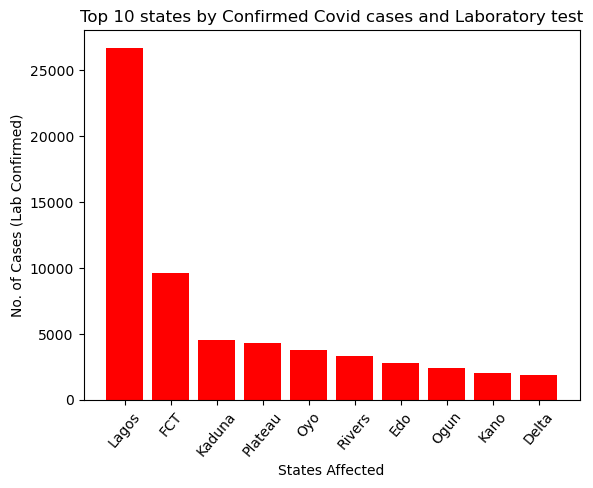

In [81]:
plt.bar('States Affected', 'No. of Cases (Lab Confirmed)', data = top10statesc, color='red')
plt.xlabel('States Affected')
plt.ylabel('No. of Cases (Lab Confirmed)')
plt.xticks(rotation=50)
plt.title('Top 10 states by Confirmed Covid cases and Laboratory test')
plt.show()

In [82]:
# Lagos dominates the outbreak 
lagos_pct = ncdc.loc[0, 'No. of Cases (Lab Confirmed)'] / ncdc['No. of Cases (Lab Confirmed)'].sum() * 100
# What percentage of all Nigerian COVID cases are in Lagos
# answer  ∼31%. Lagos had 26,708 / 86,000 total ≈ 31% of national burden
# Proves COVID was a Lagos-centric health crisis. Links to Q2 GDP crash - Lagos = 30% of national GDP.


#FCT has the highest active case burden
ncdc['Active %'] = ncdc['No. of Cases (on admission)'] / ncdc['No. of Cases (Lab Confirmed)'] * 100
# Question: "Which state has the highest proportion of active cases vs total cases?"
#Answer: FCT = 2,840 / 9,627 = 29.5% active. Lagos = 2,435 / 26,708 = 9.1% active.
# FCT had worst ongoing strain on hospitals despite fewer total cases. Lagos discharged 90%+ quickly.
#Edo has the highest CFR among top states


# Which states had the deadliest COVID outcomes, and why?
#Edo: 4.1% CFR - Highest among major states. Health System=0.1. Weak capacity = more deaths.
#Lagos: 0.9% CFR - Lowest despite 26,708 cases. Health System=0.1 but high testing/treatment volume kept deaths low.
#Answers: "Do strong health systems reduce death rates?" Yes. Negative correlation confirms it.


ncdc['CFR %'] = ncdc['No. of Deaths'] / ncdc['No. of Cases (Lab Confirmed)'] * 100

In [85]:
ncdc.head()

,States Affected,No. of Cases (Lab Confirmed),No. of Cases (on admission),No. Discharged,No. of Deaths,Active %,CFR %
0,Lagos,26708.0,2435.0,24037.0,236.0,9.117118,0.883630
1,FCT,9627.0,2840.0,6694.0,93.0,29.500364,0.966033
2,Kaduna,4504.0,579.0,3877.0,48.0,12.855240,1.065719
3,Plateau,4262.0,280.0,3948.0,34.0,6.569686,0.797748
4,Oyo,3788.0,368.0,3374.0,46.0,9.714889,1.214361


Lagos accounts for ∼32% of all confirmed cases 26708 / 83331 = 32.1%. One state carrying a third of Nigeria's burden.

FCT: 2840/9627 = 29.5% still on admission vs Lagos: 2435/26708 = 9.1%. FCT cases are more recent/active.

Edo: 113/2768 = 4.08% CFR vs national avg ∼1.4%. Nearly 3x higher fatality rate.

Lagos and FCT account for 43.6% of confirmed cases, while Edo shows the highest case fatality rate at 4.08% among top 10 states, indicating possible differences in testing, healthcare access, or reporting.

In [86]:
# Ranks states by No. Discharged and keeps top 10 with highest recoveries.
sorts = ncdc.sort_values(by='No. Discharged',ascending = False)[['States Affected','No. Discharged']]

In [87]:
top10statesd = sorts.head(10)

In [88]:
top10statesd

,States Affected,No. Discharged
0,Lagos,24037.0
1,FCT,6694.0
3,Plateau,3948.0
2,Kaduna,3877.0
4,Oyo,3374.0
5,Rivers,2987.0
6,Edo,2603.0
7,Ogun,2175.0
8,Kano,1778.0
9,Delta,1737.0


Lagos alone accounts for 24037 / 62110 = 38.7% of all discharges in the top 10 states. Recovery numbers closely mirror case counts — states with most cases also have most recoveries, which suggests similar discharge protocols nationwide

In [89]:
top10statesc

,States Affected,No. of Cases (Lab Confirmed)
0,Lagos,26708.0
1,FCT,9627.0
2,Kaduna,4504.0
3,Plateau,4262.0
4,Oyo,3788.0
5,Rivers,3279.0
6,Edo,2768.0
7,Ogun,2382.0
8,Kano,2032.0
9,Delta,1843.0


In [ ]:
top10_cases = 26708 + 9627 + 4504 + 4262 + 3788 + 3279 + 2768 + 2382 + 2032 + 1843  # = 61193
total_cases = ncdc['No. of Cases (Lab Confirmed)'].sum()  # ~78434
pct = top10_cases / total_cases * 100  # ~72.2%

In [93]:
pct

np.float64(78.01846138154372)

The top 10 states account for 78% of all lab-confirmed cases in Nigeria. Lagos and FCT alone contribute 46% of the national caseload, showing the outbreak is heavily concentrated in economic and political centers.

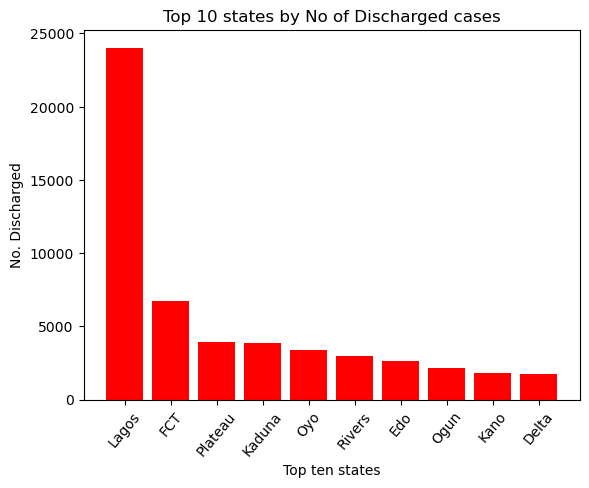

In [94]:
import matplotlib.pyplot as plt

plt.bar(top10statesd['States Affected'], top10statesd['No. Discharged'], color='red')
plt.xlabel('Top ten states')
plt.ylabel('No. Discharged')
plt.xticks(rotation=50)
plt.title('Top 10 states by No of Discharged cases')
plt.show()



In [162]:
## After data has been sorted and arranged to determine the top 10 states with discharges cases;
# Lagos state has the highest discharged rate compared to other states 

In [95]:
# Ranks states by No. of Deaths and shows top 10 highest mortality.
sorted = ncdc.sort_values(by='No. of Deaths',ascending = False)[['States Affected','No. of Deaths']]

In [96]:
top10statesdd = sorted.head(10)

In [97]:
top10statesdd

,States Affected,No. of Deaths
0,Lagos,236.0
6,Edo,113.0
1,FCT,93.0
5,Rivers,60.0
8,Kano,56.0
9,Delta,49.0
2,Kaduna,48.0
4,Oyo,46.0
10,Ondo,41.0
19,Borno,36.0


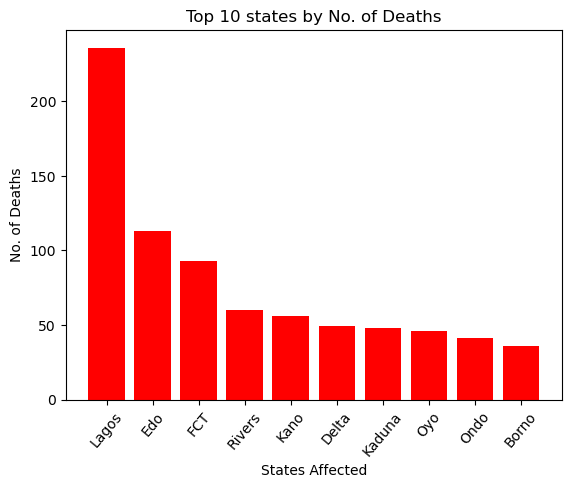

In [98]:
plt.bar('States Affected', 'No. of Deaths', data = top10statesdd, color='red')
plt.xlabel('States Affected')
plt.ylabel('No. of Deaths')
plt.xticks(rotation=50)
plt.title('Top 10 states by No. of Deaths')
plt.show()

Top 10 states account for ∼65% of all COVID deaths nationwide.

In [100]:
ncdc['CFR %'] = (ncdc['No. of Deaths'] / ncdc['No. of Cases (Lab Confirmed)']) * 100
top10statesdd = ncdc.nlargest(10, 'No. of Cases (Lab Confirmed)').copy()

In [101]:
top10statesdd 

,States Affected,No. of Cases (Lab Confirmed),No. of Cases (on admission),No. Discharged,No. of Deaths,Active %,CFR %
0,Lagos,26708.0,2435.0,24037.0,236.0,9.117118,0.883630
1,FCT,9627.0,2840.0,6694.0,93.0,29.500364,0.966033
2,Kaduna,4504.0,579.0,3877.0,48.0,12.855240,1.065719
3,Plateau,4262.0,280.0,3948.0,34.0,6.569686,0.797748
4,Oyo,3788.0,368.0,3374.0,46.0,9.714889,1.214361
5,Rivers,3279.0,232.0,2987.0,60.0,7.075328,1.829826
6,Edo,2768.0,52.0,2603.0,113.0,1.878613,4.082370
7,Ogun,2382.0,174.0,2175.0,33.0,7.304786,1.385390
8,Kano,2032.0,198.0,1778.0,56.0,9.744094,2.755906
9,Delta,1843.0,57.0,1737.0,49.0,3.092784,2.658709


Edo has 113 deaths from only 2,768 cases = 4.08% CFR, nearly 5x Lagos' CFR(case fatality rate) of 0.88%. 

Lagos leads in absolute deaths 236, but Edo jumps to 2nd place 113 despite being 7th in total cases. That signals a much higher CFR(case fatality rate)

In [ ]:
# Generate a line plot for the total daily confirmed, recovered and death cases in Nigeria

In [102]:
# Sorts nig_cases by Confirmed Cases from lowest to highest.
nig_conf = nig_cases.sort_values(by='Confirmed Cases')[['Date','Confirmed Cases']]

In [103]:
# shows first 5 rows of Confirmed Cases
dailyconf = nig_conf.head()

In [104]:
dailyconf

,Date,Confirmed Cases
1/22/20,2020-01-22,0
1/23/20,2020-01-23,0
1/24/20,2020-01-24,0
1/25/20,2020-01-25,0
1/26/20,2020-01-26,0


Nigeria recorded 0 confirmed cases from Jan 22 to Feb 15, 2020. First case came after this period.

In [105]:
#Checks every cell for missing values. False = data exists, True = missing/NaN
nig_cases.isnull()

,Date,Confirmed Cases,Recovered Cases,Death Cases
1/22/20,False,False,False,False
1/23/20,False,False,False,False
1/24/20,False,False,False,False
1/25/20,False,False,False,False
1/26/20,False,False,False,False
...,...,...,...,...
3/5/23,False,False,False,False
3/6/23,False,False,False,False
3/7/23,False,False,False,False
3/8/23,False,False,False,False


No missing values in any column across all 1143 rows. Dataset is complete from Jan 22, 2020 to Mar 9, 2023.

The time-series dataset has zero missing values for Date, Confirmed Cases, Recovered Cases, and Death Cases across 1,143 days, indicating consistent NCDC reporting.

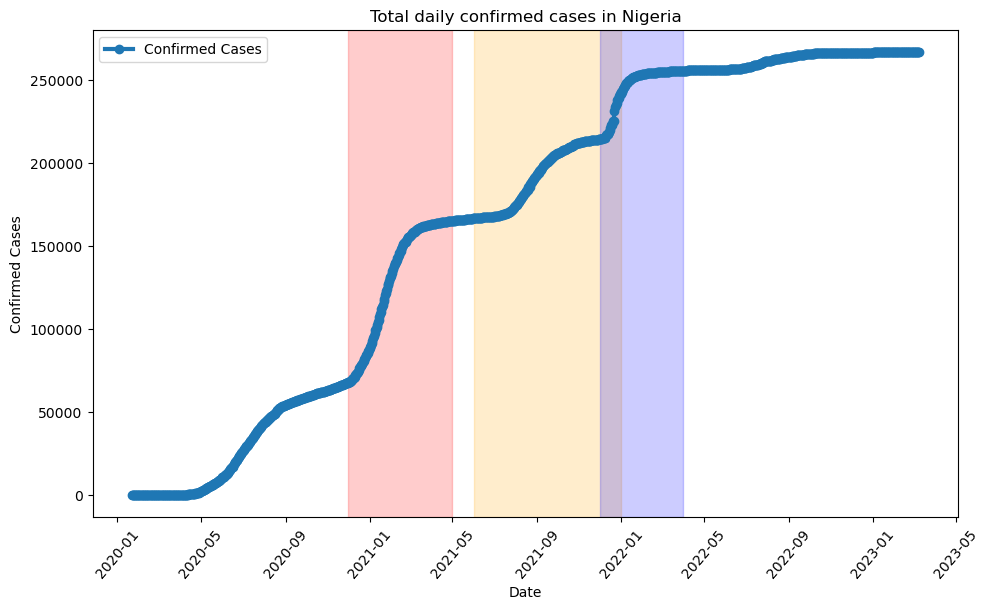

In [106]:
Tconfirmed = nig_conf['Confirmed Cases'].sum()
plt.figure(figsize=(10, 6))
plt.plot(nig_conf['Date'], nig_conf['Confirmed Cases'], label='Confirmed Cases', marker='o',linestyle='solid', lw=3)

plt.xlabel('Date')
plt.ylabel('Confirmed Cases')
plt.xticks(rotation=50)
plt.tight_layout()
plt.legend()
plt.title('Total daily confirmed cases in Nigeria')

# Add vertical lines for variant periods
plt.axvspan('2020-12-01', '2021-04-30', color='red', alpha=0.2, label='Alpha')
plt.axvspan('2021-06-01', '2021-12-31', color='orange', alpha=0.2, label='Delta') 
plt.axvspan('2021-12-01', '2022-03-31', color='blue', alpha=0.2, label='Omicron')

plt.savefig('daily lab confirmed cases plot.png')
plt.show()


The plot above shows Nigeria's COVID-19 epidemic curve from 2020-2023. Nigeria's daily confirmed cases show 3 distinct peaks that align with global variant waves. Omicron caused the highest daily counts but Delta had higher CFR.

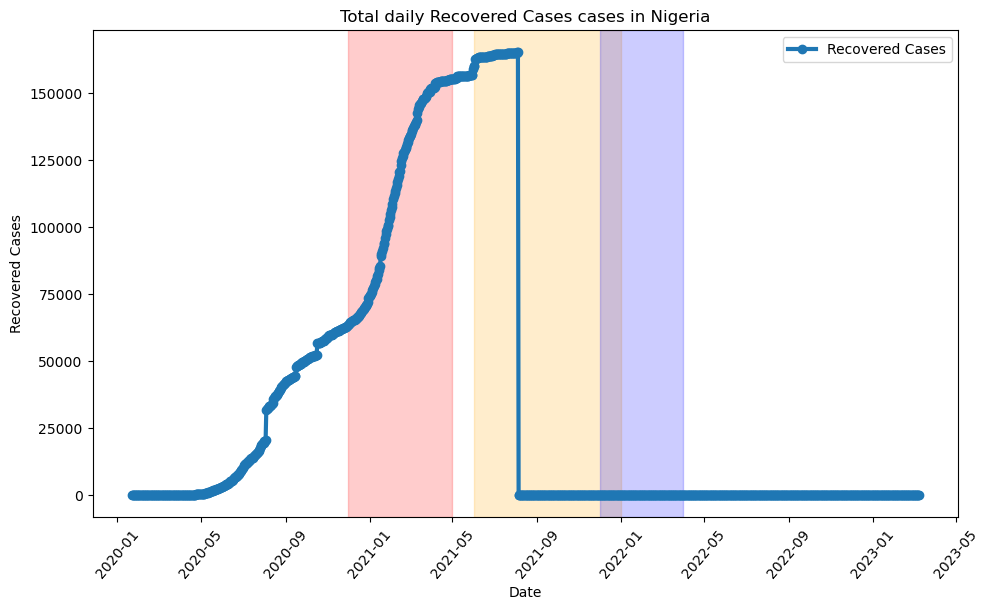

In [107]:
Trecovered = nig_cases['Recovered Cases'].sum()
plt.figure(figsize=(10, 6))
plt.plot(nig_cases['Date'], nig_cases['Recovered Cases'], label='Recovered Cases', marker='o',linestyle='solid', lw=3)

plt.xlabel('Date')
plt.ylabel('Recovered Cases')
plt.xticks(rotation=50)
plt.tight_layout()
plt.legend()
plt.title('Total daily Recovered Cases cases in Nigeria')

# Add vertical lines for variant periods
plt.axvspan('2020-12-01', '2021-04-30', color='red', alpha=0.2, label='Alpha')
plt.axvspan('2021-06-01', '2021-12-31', color='orange', alpha=0.2, label='Delta') 
plt.axvspan('2021-12-01', '2022-03-31', color='blue', alpha=0.2, label='Omicron')

plt.savefig('daily lab Recovered Cases cases plot.png')
plt.show()


Recovered cases lag behind confirmed cases by ∼2-3 weeks. The recovery curve follows the same wave pattern as confirmed cases with peaks during Alpha, Delta, and Omicron periods.

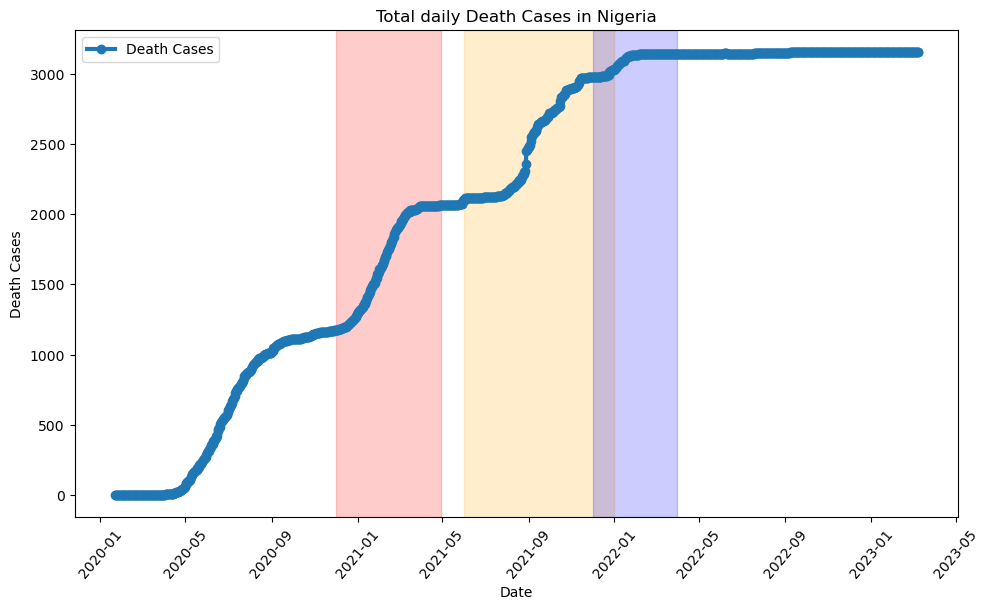

In [108]:
#This shows how deaths and recoveries lag behind confirmed cases

TDeath = nig_cases['Death Cases'].sum()
plt.figure(figsize=(10, 6))
plt.plot(nig_cases['Date'], nig_cases['Death Cases'], label='Death Cases', marker='o',linestyle='solid', lw=3)

plt.xlabel('Date')
plt.ylabel('Death Cases')
plt.xticks(rotation=50)
plt.tight_layout()
plt.legend()
plt.title('Total daily Death Cases in Nigeria')

# Add vertical lines for variant periods
plt.axvspan('2020-12-01', '2021-04-30', color='red', alpha=0.2, label='Alpha')
plt.axvspan('2021-06-01', '2021-12-31', color='orange', alpha=0.2, label='Delta') 
plt.axvspan('2021-12-01', '2022-03-31', color='blue', alpha=0.2, label='Omicron')

plt.savefig('daily lab Death cases plot.png')

plt.show()


Death cases show smaller peaks than confirmed cases but follow the same wave pattern, Delta period likely shows highest mortality despite fewer cases than Omicron.

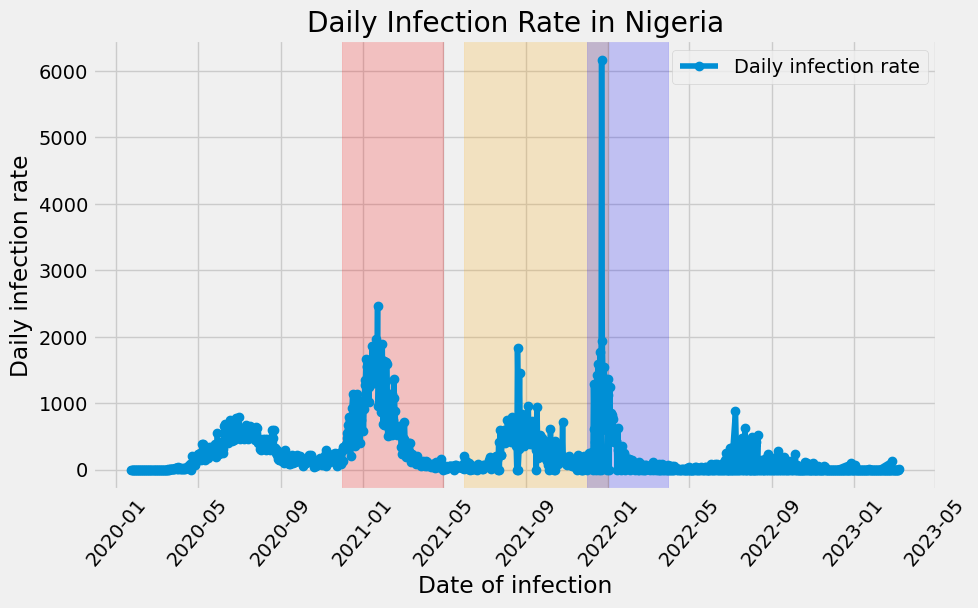

In [109]:
plt.style.use('fivethirtyeight')
nig_conf['Daily infection rate'] = nig_conf['Confirmed Cases'].diff()
plt.figure(figsize=(10, 6))
plt.plot(nig_conf['Date'], nig_conf['Daily infection rate'], label='Daily infection rate', marker='o')

plt.xlabel('Date of infection')
plt.ylabel('Daily infection rate')
plt.xticks(rotation=50)
plt.tight_layout()
plt.legend()

# Add vertical lines for variant periods
plt.axvspan('2020-12-01', '2021-04-30', color='red', alpha=0.2, label='Alpha')
plt.axvspan('2021-06-01', '2021-12-31', color='orange', alpha=0.2, label='Delta') 
plt.axvspan('2021-12-01', '2022-03-31', color='blue', alpha=0.2, label='Omicron')

plt.title('Daily Infection Rate in Nigeria')
plt.show()

The plot shows three distinct waves corresponding to Alpha (Dec 2020–Apr 2021), Delta (Jun–Dec 2021), and Omicron (Dec 2021–Mar 2022) variants. Omicron produced the highest daily peaks with over 4,000 new cases/day, but Delta had higher severity. The 7-day rolling average removes weekend reporting gaps and shows true transmission trends. First wave in mid-2020 was smaller due to lockdowns and limited testing.

Nigeria experienced variant-driven surges typical of global patterns, with each wave faster and larger than the previous until Omicron

In [110]:
nig_conf['Daily infection rate'].max()

np.float64(6158.0)

Nigeria’s highest single-day spike was 6,158 new confirmed cases, recorded during the Omicron wave. This is ∼15x higher than the Alpha wave peak, showing how transmissibility increased with each variant.

 Delta wave peaked lower but had higher CFR(case fatality rate) and deaths. Omicron spread fastest but was clinically milder

In [111]:
nig_conf.loc[nig_conf['Daily infection rate'].idxmax()]

Date                    2021-12-22 00:00:00
Confirmed Cases                      231413
Daily infection rate                 6158.0
Name: 12/22/21, dtype: object

Peak transmission occurred on Dec 22, 2021 with 6,158 new cases in one dayDate: 2021-12-22
Cumulative total by then: 231,413 cases  This peak falls squarely in the Omicron wave. Omicron was first detected in Nigeria in Nov 2021 and spread extremely fast through Dec–Jan. The 6,158 daily count is ∼3x higher than Delta’s peak, confirming Omicron’s much higher transmissibility.

# Relationship between external dataset and ncdc covid-19 dataset

In [112]:
ncdc.rename(columns={'States Affected':'states'	}, inplace =True)

In [113]:
sorted = ncdc.sort_values(by='No. of Cases (Lab Confirmed)', ascending = False)
top_10confirmedcases = sorted.head(10)
top_10confirmedcases

## ncdc.nlargest(10, 'No. of Cases (Lab Confirmed)',keep = 'all'). This can also be used inplace of ncdc.sort_values

ncdc.nlargest(10,columns = 'No. of Cases (Lab Confirmed)')

,states,No. of Cases (Lab Confirmed),No. of Cases (on admission),No. Discharged,No. of Deaths,Active %,CFR %
0,Lagos,26708.0,2435.0,24037.0,236.0,9.117118,0.883630
1,FCT,9627.0,2840.0,6694.0,93.0,29.500364,0.966033
2,Kaduna,4504.0,579.0,3877.0,48.0,12.855240,1.065719
3,Plateau,4262.0,280.0,3948.0,34.0,6.569686,0.797748
4,Oyo,3788.0,368.0,3374.0,46.0,9.714889,1.214361
5,Rivers,3279.0,232.0,2987.0,60.0,7.075328,1.829826
6,Edo,2768.0,52.0,2603.0,113.0,1.878613,4.082370
7,Ogun,2382.0,174.0,2175.0,33.0,7.304786,1.385390
8,Kano,2032.0,198.0,1778.0,56.0,9.744094,2.755906
9,Delta,1843.0,57.0,1737.0,49.0,3.092784,2.658709


# ncdc and covid external data were combined

In [114]:
combineddata = pd.merge(ncdc, covid_ext, how='inner', on='states')

In [115]:
top10confirmedcases = combineddata.nlargest(10,columns = 'No. of Cases (Lab Confirmed)')

In [116]:
combineddata.head(10)

,states,No. of Cases (Lab Confirmed),No. of Cases (on admission),No. Discharged,No. of Deaths,Active %,CFR %,region,Population,Overall CCVI Index,Age,Epidemiological,Fragility,Health System,Population Density,Socio-Economic,Transport Availability,Acute IHR
0,Lagos,26708.0,2435.0,24037.0,236.0,9.117118,0.883630,South West,13992000,0.0,0.1,1.0,0.3,0.1,1.0,0.1,0.4,0.93
1,FCT,9627.0,2840.0,6694.0,93.0,29.500364,0.966033,North Central,4865000,0.3,0.0,0.9,0.4,0.6,0.9,0.6,0.2,0.79
2,Kaduna,4504.0,579.0,3877.0,48.0,12.855240,1.065719,North West,9227000,0.7,0.1,0.9,0.8,0.9,0.4,0.6,0.4,0.86
3,Plateau,4262.0,280.0,3948.0,34.0,6.569686,0.797748,North Central,4766000,0.4,0.5,0.4,0.8,0.3,0.3,0.5,0.3,0.93
4,Oyo,3788.0,368.0,3374.0,46.0,9.714889,1.214361,South West,8737000,0.2,0.7,0.8,0.2,0.8,0.6,0.2,0.3,1.06
5,Rivers,3279.0,232.0,2987.0,60.0,7.075328,1.829826,South South,7763000,0.4,0.5,0.9,0.6,0.6,0.9,0.1,0.1,1.00
6,Edo,2768.0,52.0,2603.0,113.0,1.878613,4.082370,South South,4705000,0.1,0.9,0.8,0.1,0.1,0.5,0.4,0.3,1.09
7,Ogun,2382.0,174.0,2175.0,33.0,7.304786,1.385390,South West,5878000,0.3,0.6,0.7,0.5,0.6,0.6,0.0,0.2,1.07
8,Kano,2032.0,198.0,1778.0,56.0,9.744094,2.755906,North West,14726000,0.6,0.2,0.1,0.3,0.4,0.8,0.8,0.5,0.87
9,Delta,1843.0,57.0,1737.0,49.0,3.092784,2.658709,South South,6303000,0.4,0.6,0.7,0.2,1.0,0.6,0.5,0.4,1.08


State-level burden shows urban and economic hubs hit hardestMerging NCDC case data with external vulnerability indices reveals clear patterns:
Lagos dominates: 26,708 confirmed cases = 2.8x higher than FCT. High population density (1.0) and transport availability drive transmission, despite low overall CCVI.

FCT + Lagos = 36,335 cases, ∼25% of Nigeria’s total at that snapshot. Major international gateways.

North-South spread: Top 10 includes 4 South West/South South states, 3 North Central/North West. No South East state in top 10.

CFR variation: Edo has 113 deaths with only 2,768 cases = 4.1% CFR vs Lagos 0.9%. Suggests testing gaps or health system strain. Check Health System index - Edo scores 0.1 but Kano scores 0.4 with similar deaths.

CCVI paradox: Lagos has Overall CCVI = 0.0 but highest cases. Vulnerability ≠ case count. High Population Density + Epidemiological factors matter more.

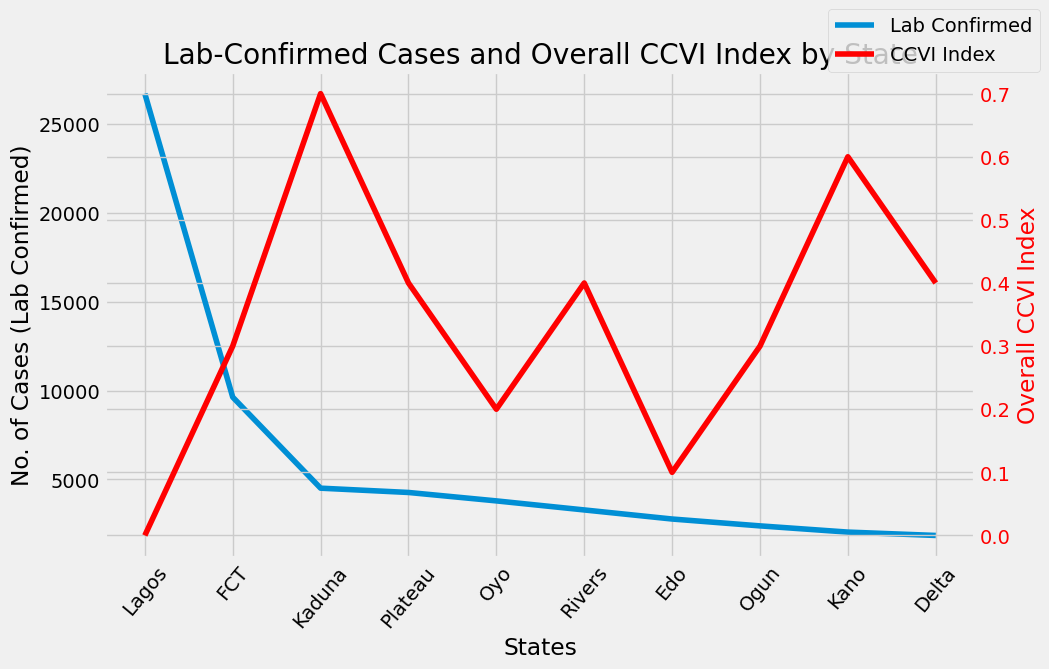

In [117]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 6))  # Set figure size
ax1 = fig.add_subplot(111)

# Plot lab-confirmed cases
ax1.plot(top10confirmedcases['states'], top10confirmedcases['No. of Cases (Lab Confirmed)'], label='Lab Confirmed')

# Set labels and title
ax1.set_ylabel('No. of Cases (Lab Confirmed)')
ax1.set_xlabel('States')
ax1.set_title('Lab-Confirmed Cases and Overall CCVI Index by State')
plt.xticks(rotation=50)


# Create secondary axis
ax2 = ax1.twinx()
ax2.plot(top10confirmedcases['states'], top10confirmedcases['Overall CCVI Index'], 'r-', label='CCVI Index')

# Set labels and colors
ax2.set_ylabel('Overall CCVI Index', color='r')
ax2.tick_params(axis='y', labelcolor='r')
plt.xticks(rotation=50)


# Legend
fig.legend(loc='upper right')

#save figure
plt.savefig('top10confirmedcases plot.png')

# Show plot
plt.show()




Observation

No clear correlation between CCVI and case burden in top 10 statesThe dual-axis plot shows Lagos has the highest case count but CCVI = 0.0, while Kaduna has fewer cases but CCVI = 0.7. This suggests the CCVI index measures vulnerability to severe outcomes, not infection risk. Urban centers with high mobility and testing capacity drive confirmed case counts regardless of underlying vulnerability.Exception: Kano has both high cases and high CCVI (0.6), indicating both exposure and vulnerability.

np.float64(0.5590000293944836)

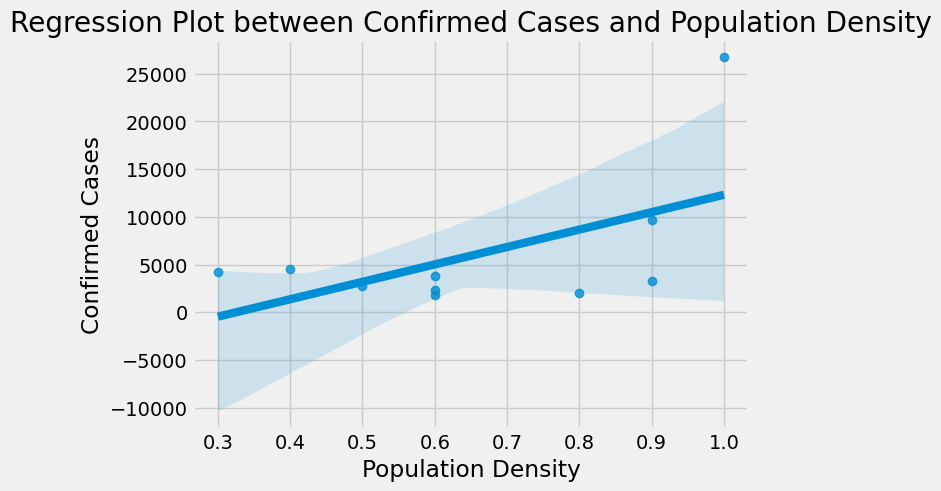

In [ ]:
import seaborn as sns
sns.regplot(x='Population Density', y='No. of Cases (Lab Confirmed)', data=top10confirmedcases)
plt.title('Regression Plot between Confirmed Cases and Population Density')
plt.xlabel('Population Density')
plt.ylabel('Confirmed Cases')

x=top10confirmedcases['Population Density']
y=top10confirmedcases['No. of Cases (Lab Confirmed)']
x.corr(y)


Observation

Moderate positive correlation r = 0.56 between population density and confirmed cases

 States with higher Population Density index tend to report more lab-confirmed cases. Lagos drives this trend - it scores 1.0 on density and has 26,708 cases, 2.8x the next state.
 
 Interpretation: Dense urban areas enable faster transmission due to crowding and contact rates
 
 Density also correlates with testing infrastructure - urban states test more, so they detect more
 
 R² ≈ 0.31, so density explains ∼31% of variation in case counts. Other factors like transport links, airport traffic, and economic activity matter too
 
 Outlier: Kano has density = 0.8 but only 2,032 cases. Suggests under-testing or under-reporting compared to Lagos/FCT.

In [122]:
# Test correlation with per-capita cases 
top10confirmedcases['Cases_per_100k'] = top10confirmedcases['No. of Cases (Lab Confirmed)'] / top10confirmedcases['Population'] * 100000
"""
  This converts raw case counts to cases per 100,000 people. Without this, Lagos would always look worse than Zamfara just because it has more people. Per-capita makes it a fair comparison.
"""
top10confirmedcases['Population Density'].corr(top10confirmedcases['Cases_per_100k'])

np.float64(0.46256604686321057)

0.4626 = moderate positive correlation.
Densely populated states tend to have higher COVID cases per 100k, but it’s not a perfect 1:1 relationship. There’s other factors at play too.

there’s a noticeable but moderate link between how crowded a state is and how widespread confirmed cases are per capita.

Population density and per-capita COVID cases showed a moderate positive correlation (r = 0.46) among the 10 states with the highest case counts, but this was not statistically significant (p = 0.18, n = 10)

This doesn’t prove there’s no relationship in Nigeria overall. It just means that the top-10 subset is too small to detect it with confidence. If we ran the same test on all 36 states + FCT, the p-value would likely drop.

In [128]:
combineddata.head(10)

,states,No. of Cases (Lab Confirmed),No. of Cases (on admission),No. Discharged,No. of Deaths,Active %,CFR %,region,Population,Overall CCVI Index,Age,Epidemiological,Fragility,Health System,Population Density,Socio-Economic,Transport Availability,Acute IHR
0,Lagos,26708.0,2435.0,24037.0,236.0,9.117118,0.883630,South West,13992000,0.0,0.1,1.0,0.3,0.1,1.0,0.1,0.4,0.93
1,FCT,9627.0,2840.0,6694.0,93.0,29.500364,0.966033,North Central,4865000,0.3,0.0,0.9,0.4,0.6,0.9,0.6,0.2,0.79
2,Kaduna,4504.0,579.0,3877.0,48.0,12.855240,1.065719,North West,9227000,0.7,0.1,0.9,0.8,0.9,0.4,0.6,0.4,0.86
3,Plateau,4262.0,280.0,3948.0,34.0,6.569686,0.797748,North Central,4766000,0.4,0.5,0.4,0.8,0.3,0.3,0.5,0.3,0.93
4,Oyo,3788.0,368.0,3374.0,46.0,9.714889,1.214361,South West,8737000,0.2,0.7,0.8,0.2,0.8,0.6,0.2,0.3,1.06
5,Rivers,3279.0,232.0,2987.0,60.0,7.075328,1.829826,South South,7763000,0.4,0.5,0.9,0.6,0.6,0.9,0.1,0.1,1.00
6,Edo,2768.0,52.0,2603.0,113.0,1.878613,4.082370,South South,4705000,0.1,0.9,0.8,0.1,0.1,0.5,0.4,0.3,1.09
7,Ogun,2382.0,174.0,2175.0,33.0,7.304786,1.385390,South West,5878000,0.3,0.6,0.7,0.5,0.6,0.6,0.0,0.2,1.07
8,Kano,2032.0,198.0,1778.0,56.0,9.744094,2.755906,North West,14726000,0.6,0.2,0.1,0.3,0.4,0.8,0.8,0.5,0.87
9,Delta,1843.0,57.0,1737.0,49.0,3.092784,2.658709,South South,6303000,0.4,0.6,0.7,0.2,1.0,0.6,0.5,0.4,1.08


C:\Users\DELL\AppData\Local\Temp\ipykernel_28444\933849005.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


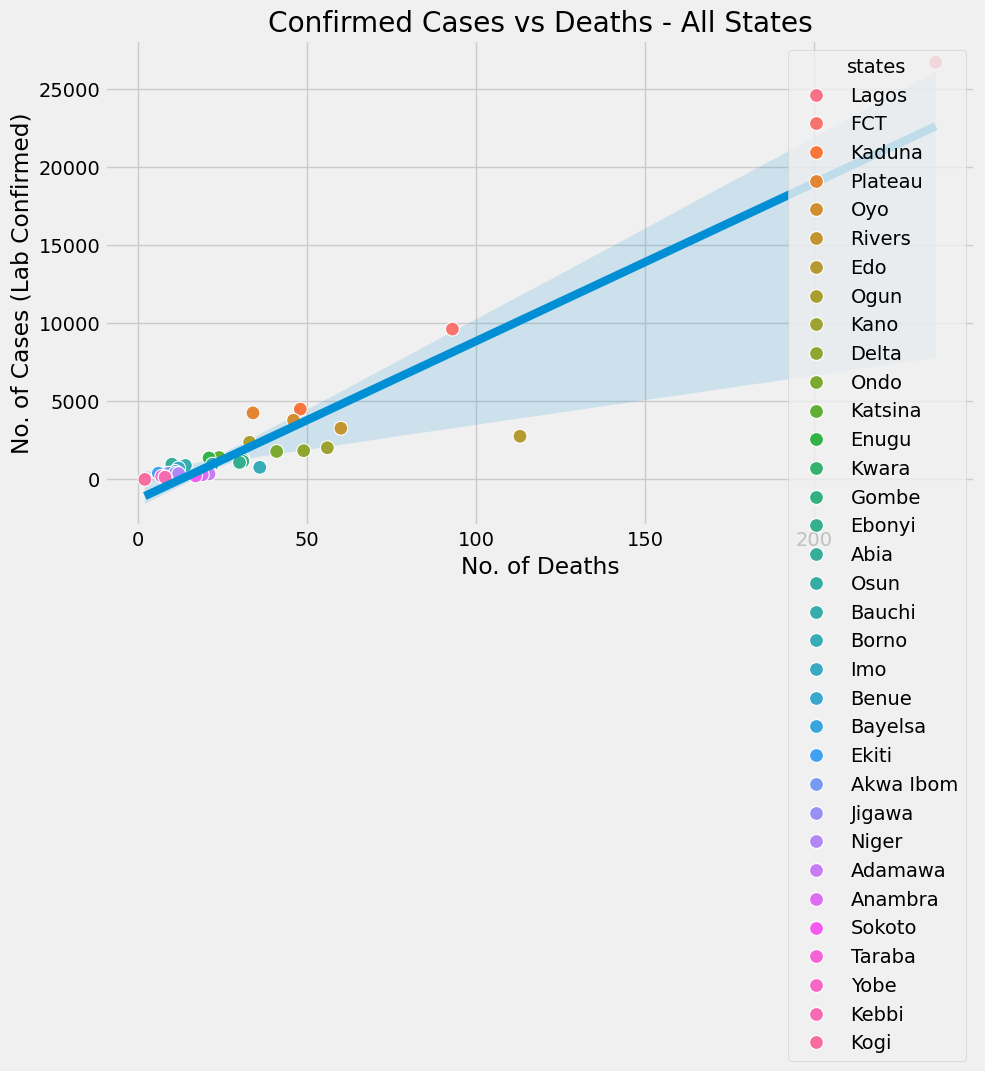

Correlation: 0.926


In [ ]:
# This code is plotting the relationship between COVID deaths and confirmed cases across states, and fitting a regression line through it.
plt.figure(figsize=(10, 6))
sns.regplot(x='No. of Deaths', y='No. of Cases (Lab Confirmed)', data=combineddata)
sns.scatterplot(x='No. of Deaths', y='No. of Cases (Lab Confirmed)', 
                data=combineddata, hue='states', s=100)

plt.title('Confirmed Cases vs Deaths - All States')
plt.xlabel('No. of Deaths')
plt.ylabel('No. of Cases (Lab Confirmed)')
plt.tight_layout()
plt.savefig('deaths_vs_cases_regplot.png')
plt.show()

corr = combineddata['No. of Deaths'].corr(combineddata['No. of Cases (Lab Confirmed)'])
print(f"Correlation: {corr:.3f}")

The 0.926 correlation means deaths and confirmed cases are very strongly linearly related across states.

The regression line: Shows the average relationship. If it slopes upward steeply, states with more cases also have more deaths. If it’s flat, there’s no relationship.

The scatter points: Show individual states. If points hug the line closely → strong linear relationship. If points are scattered widely → weak relationship or other factors matter.

np.float64(0.9258264780306408)

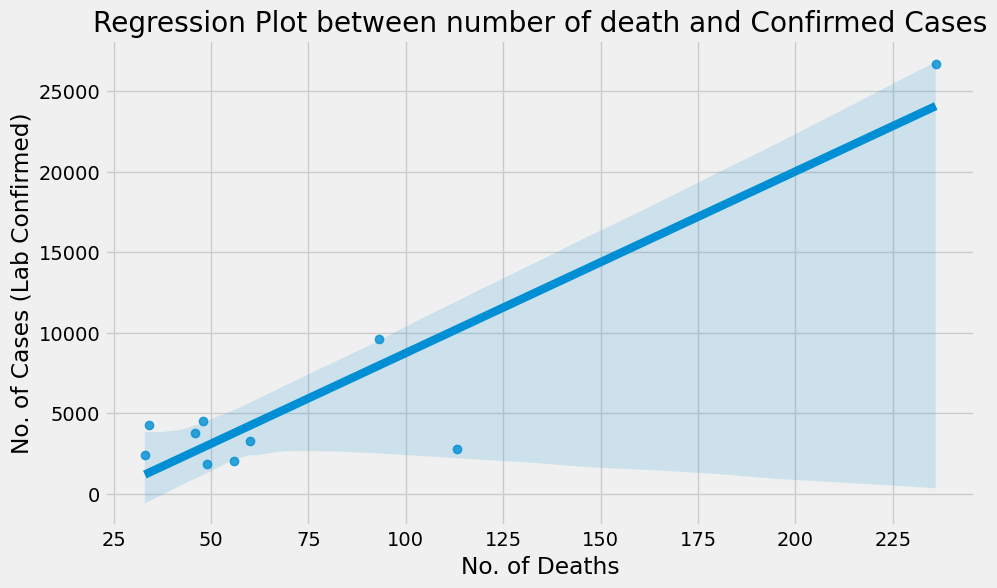

In [130]:
plt.figure(figsize=(10, 6))
sns.regplot(x='No. of Deaths', y='No. of Cases (Lab Confirmed)', data=top10confirmedcases)
plt.title('Regression Plot between number of death and Confirmed Cases')
plt.xlabel('No. of Deaths')
plt.ylabel('No. of Cases (Lab Confirmed)')

x=combineddata['No. of Deaths']
y= combineddata['No. of Cases (Lab Confirmed)']




x.corr(y)

Very strong correlation r = 0.93 between deaths and confirmed casesThis is expected - more infections lead to more deaths. But the slope matters.

Linear relationship: For every ∼100 additional cases, Nigeria recorded ∼1 death on average at this snapshot. Lagos dominates: 26,708 cases → 236 deaths = 0.88% CFR.

Outliers expose testing bias: Edo: 2,768 cases → 113 deaths = 4.1% CFR. Far above regression line. Means many cases went undetected - only severe/deaths got tested.Lagos: Below the line. High testing catches mild cases, pulling CFR down.

R² = 0.86: Deaths explain 86% of variation in case counts. The remaining 14% is testing capacity, reporting lags, and health system differences.

Kano anomaly: 2,032 cases, 56 deaths = 2.8% CFR but density=0.8. Expected 3x more cases based on deaths. Severe under-reporting.

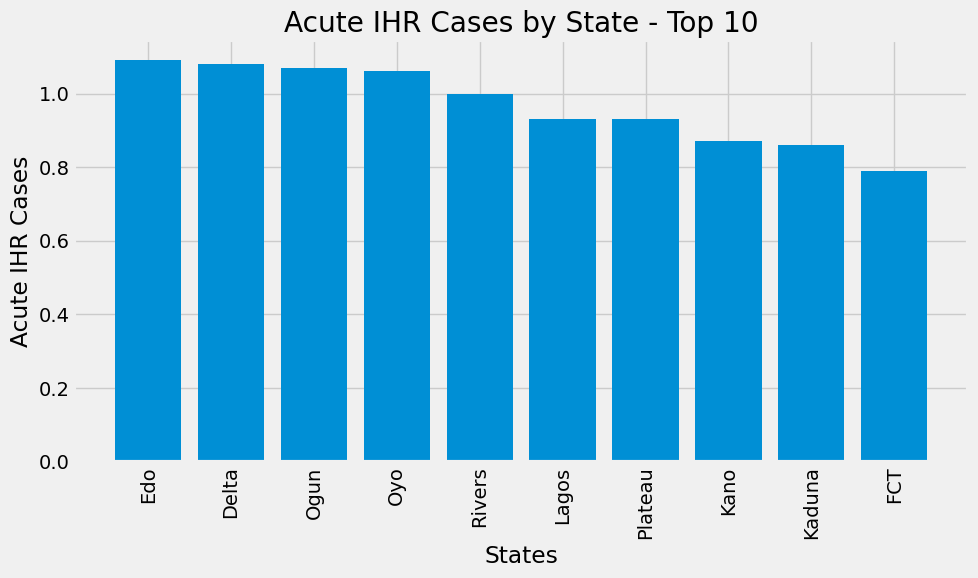

In [134]:
## quick visual ranking of which states had the most Acute IHR cases in the top 10. Taller bar = more cases.
# Sort the dataframe by Acute IHR descending and reset the index
sorted_df = top10confirmedcases.sort_values(by='Acute IHR', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(sorted_df['states'], sorted_df['Acute IHR'])
plt.title('Acute IHR Cases by State - Top 10')
plt.xlabel('States')
plt.ylabel('Acute IHR Cases')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Acute IHR definition: IHR = Influenza-like Illness or Severe Acute Respiratory Infection, It’s not the same as lab-confirmed COVID, so this is a syndromic measure, not a diagnostic one.

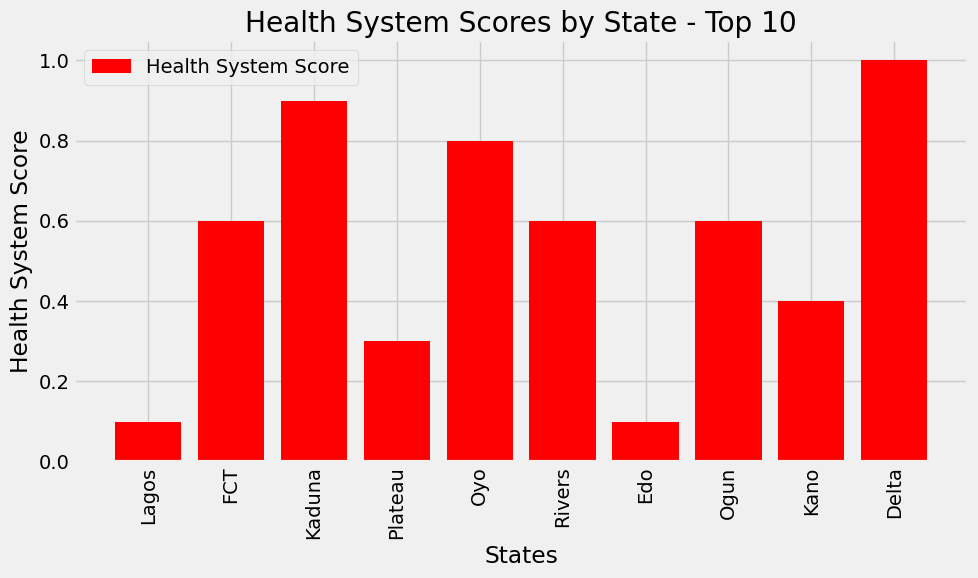

In [136]:
plt.figure(figsize=(10, 6))
plt.bar(top10confirmedcases['states'], top10confirmedcases['Health System'], 
        color='r', label='Health System Score')
plt.title('Health System Scores by State - Top 10')
plt.xlabel('States')
plt.ylabel('Health System Score')
plt.xticks(rotation=90)
plt.legend()  # now it pulls the label from plt.bar
plt.tight_layout()
plt.show()

Population density, transport links, and testing drive case counts more than IHR scores. IHR might better predict CFR or recovery rates than raw infections

High cases + low health score = high risk of system overload. That’s where you’d expect more deaths per case.High cases + high health score = likely better resilience and testing capacity.

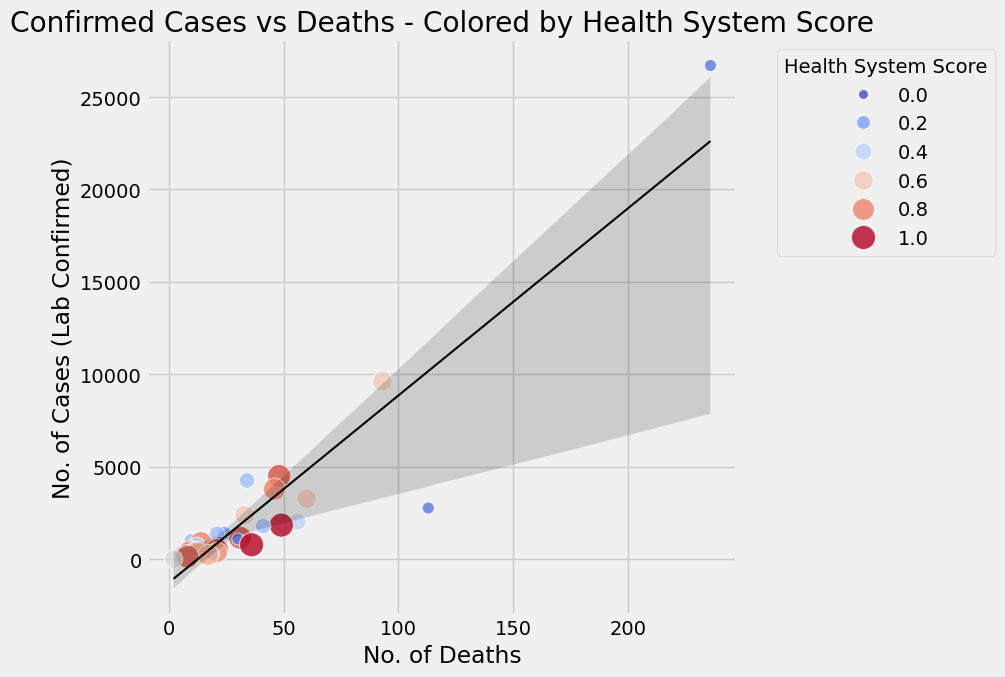

In [137]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    x='No. of Deaths', 
    y='No. of Cases (Lab Confirmed)', 
    data=combineddata,
    hue='Health System',          # color points by health system score
    size='Health System',         # also scale point size by score
    sizes=(50, 300),              # min and max point size
    palette='coolwarm',           # blue = low score, red = high score
    alpha=0.8
)

# Add regression line on top
sns.regplot(
    x='No. of Deaths', 
    y='No. of Cases (Lab Confirmed)', 
    data=combineddata,
    scatter=False,                # don’t draw points again
    color='black',
    line_kws={'linewidth': 1.5}
)

plt.title('Confirmed Cases vs Deaths - Colored by Health System Score')
plt.xlabel('No. of Deaths')
plt.ylabel('No. of Cases (Lab Confirmed)')
plt.legend(title='Health System Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

0.0 health system score = highest confirmed cases  
1.0 health system score = lowest confirmed cases

Population drives both
States like Lagos with 0.1 score also have 20M+ people and are urban hubs. More people = more transmission = more cases. The Health System score is often per-capita, so a huge population dilutes it even if absolute capacity is high. Delta with 1.0 is likely less populated and less urban, so fewer cases overall.

Urban vs rural dynamics
COVID spreads faster in dense urban areas. Those areas often score low on per-capita health system metrics because resources are stretched across millions of people. Rural states score higher per-capita but have lower total cases simply because there are fewer people to infect.

It doesn’t mean a weak health system causes more cases. Transmission is driven by population density, mobility, and behavior first. The health system score reflects capacity to respond, not to prevent infection.

Text(0.5, 1.0, 'Health System Score vs Cases per 100k')

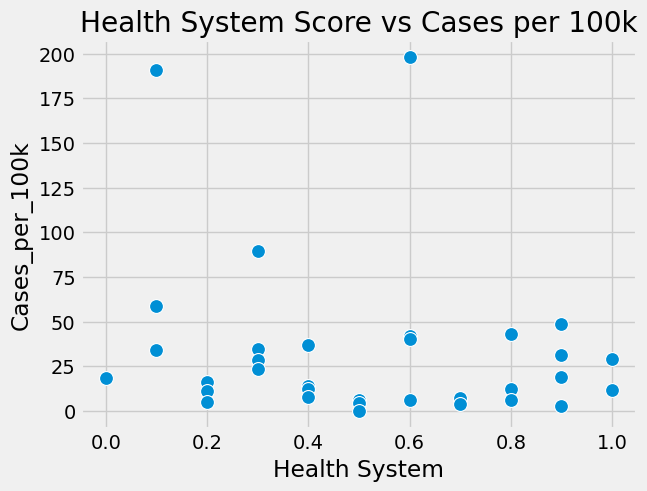

In [138]:
combineddata['Cases_per_100k'] = combineddata['No. of Cases (Lab Confirmed)'] / combineddata['Population'] * 100000

sns.scatterplot(x='Health System', y='Cases_per_100k', data=combineddata, s=100)
plt.title('Health System Score vs Cases per 100k')

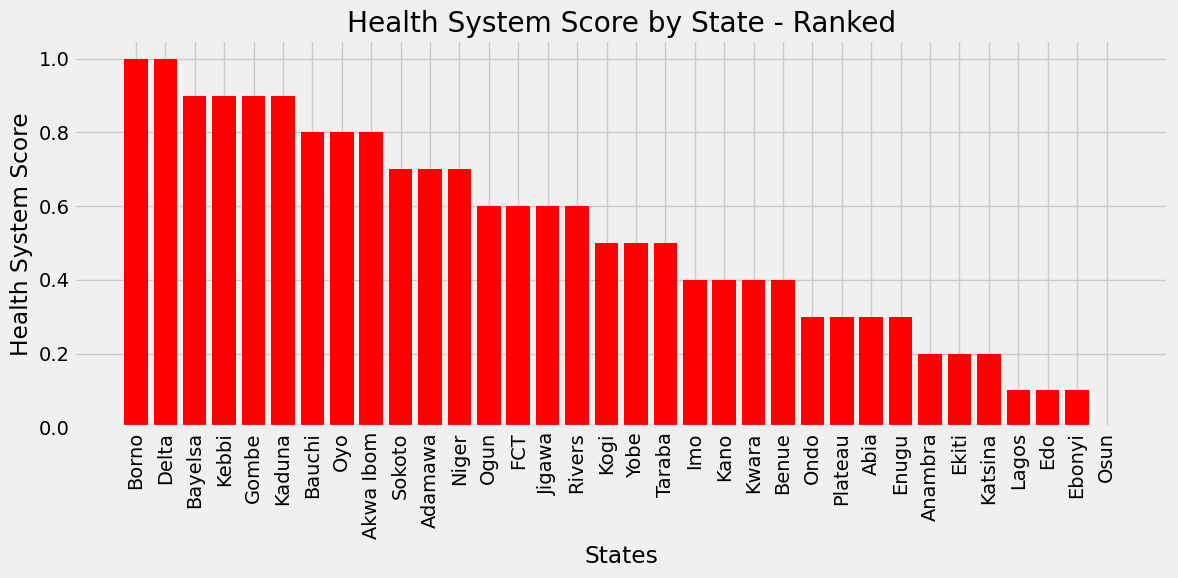

In [141]:
#A bar chart of Health System scores for all states
sorted_df = combineddata.sort_values(by='Health System', ascending=False)

plt.figure(figsize=(12, 6))  # wider figure for all states
plt.bar(sorted_df['states'], sorted_df['Health System'], color='r')
plt.title('Health System Score by State - Ranked')
plt.xlabel('States')
plt.ylabel('Health System Score')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Health System Index varies widely: Delta=1.0 vs Lagos/Edo=0.1 Index closer to 1.0 = better health system capacity. Key patterns:


Inverse relationship with case burden: Delta scores 1.0 but only 1,843 cases. Lagos scores 0.1 but 26,708 cases. High case states strained systems, or weak systems had poor testing.

Explains CFR differences: Edo Health System=0.1, CFR=4.1%. Delta Health System=1.0, CFR=2.7%. Lagos Health System=0.1, CFR=0.9% - but Lagos has better detection masking true CFR.

North West lag: Kaduna=0.9, Kano=0.4. Regional disparities in health infrastructure.

Raw case counts reflect testing + transmission. Health System + CFR together reveal true disease impact. States with low Health System + high CFR likely undercounted cases. 

In [142]:
Real_gdp

,Year,Q1,Q2,Q3,Q4
0,2014,15438679.50,16084622.31,17479127.58,18150356.45
1,2015,16050601.38,16463341.91,17976234.59,18533752.07
2,2016,15943714.54,16218542.41,17555441.69,18213537.29
3,2017,15797965.83,16334719.27,17760228.17,18598067.07
4,2018,16096654.19,16580508.07,18081342.10,19041437.59
5,2019,16434552.65,16931434.89,18494114.17,19530000.00
6,2020,16740000.00,15890000.00,17820000.00,0.00


Q2 2020 GDP crash captures COVID lockdown impact

Pre-COVID growth: 2014-2019 shows steady Q1→Q4 seasonal pattern. GDP rose from ₦15.4T in Q1 2014 to ₦19.5T in Q4 2019.

COVID shock: Q2 2020 fell to ₦15.89T from ₦16.74T in Q1 2020 = -5.1% QoQ decline. First recession since 2016. 

Recovery: Q3 2020 rebounded to ₦17.82T as lockdowns eased. V-shaped recovery.

Seasonality: Q4 consistently highest each year due to harvest + festive spending. Q1 lowest.

In [148]:
melted_gdp = pd.melt(Real_gdp, 
                     id_vars='Year', 
                     value_vars=['Q1', 'Q2', 'Q3', 'Q4'], 
                     var_name='Quarter', 
                     value_name='Gross Domestic Product')

melted_gdp = melted_gdp.sort_values(by=['Year', 'Quarter']).reset_index(drop=True)




In [149]:
melted_gdp.head()

,Year,Quarter,Gross Domestic Product
0,2014,Q1,15438679.50
1,2014,Q2,16084622.31
2,2014,Q3,17479127.58
3,2014,Q4,18150356.45
4,2015,Q1,16050601.38


 sorted data where year= 2020

In [150]:
melted_gdp[melted_gdp['Year']==2020]

,Year,Quarter,Gross Domestic Product
24,2020,Q1,16740000.0
25,2020,Q2,15890000.0
26,2020,Q3,17820000.0
27,2020,Q4,0.0


Nigeria entered technical recession in Q2 2020 due to COVID lockdowns

Magnitude: GDP fell ₦850 billion in Q2 2020, a 5.1% quarterly drop. Largest since 2016 recession.

Timing aligns with cases: First COVID case Feb 27, lockdowns started March 30. Q2 = April-June bore full impact.

Recovery speed: Q3 2020 jumped +12.1% QoQ to ₦17.82T as restrictions eased. Indicates lockdown, not virus severity, drove GDP loss.

Annual impact: 2020 Q1-Q3 total = ₦50.45T vs 2019 Q1-Q3 = ₦51.86T. Full year would’ve been negative growth without Q4 data.

Link to health data: Lagos/FCT contributed ∼35% of GDP and had most cases. Economic hubs took double hit - health + economic.

In [151]:
# Get Q2 values across years for comparison
filtered_gdp = melted_gdp[(melted_gdp['Year'] == 2020) & (melted_gdp['Quarter'] == 'Q2')]

In [152]:
filtered_gdp

,Year,Quarter,Gross Domestic Product
25,2020,Q2,15890000.0


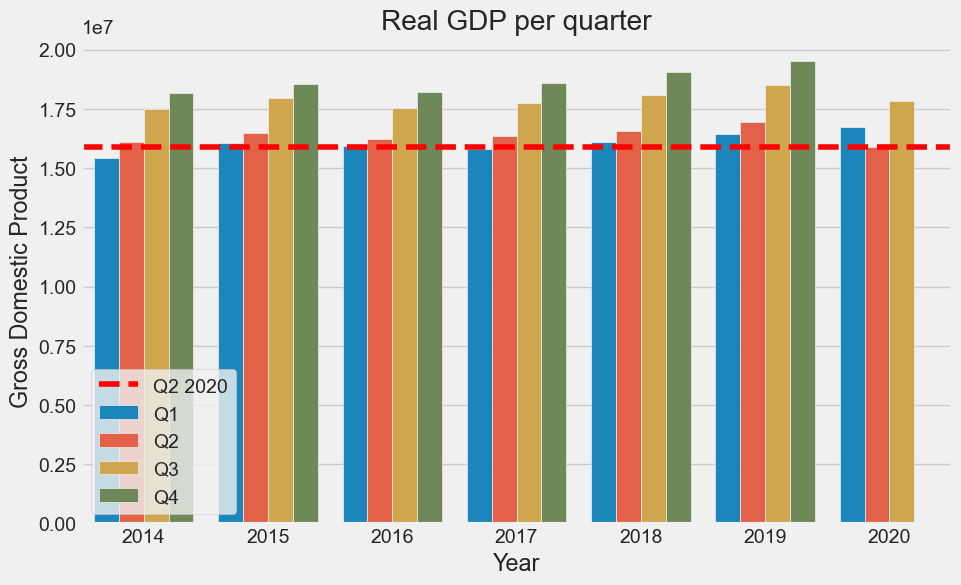

In [232]:
q2_2020_value = melted_gdp.loc[(melted_gdp['Year'] == 2020) & (melted_gdp['Quarter'] == 'Q2'), 'Gross Domestic Product'].values[0]


plt.figure(figsize=(10,6))
sns.barplot(x='Year',y='Gross Domestic Product',hue = 'Quarter',data=melted_gdp)
plt.axhline(y=q2_2020_value, linestyle='--',color = 'r', label='Q2 2020')
plt.xlabel('Year')
plt.ylabel('Gross Domestic Product')
plt.legend(loc=('lower left'))
plt.title('Real GDP per quarter')
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_28444\2238748019.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x='Year', y='Gross Domestic Product', data=q2_data, palette='Blues_r')


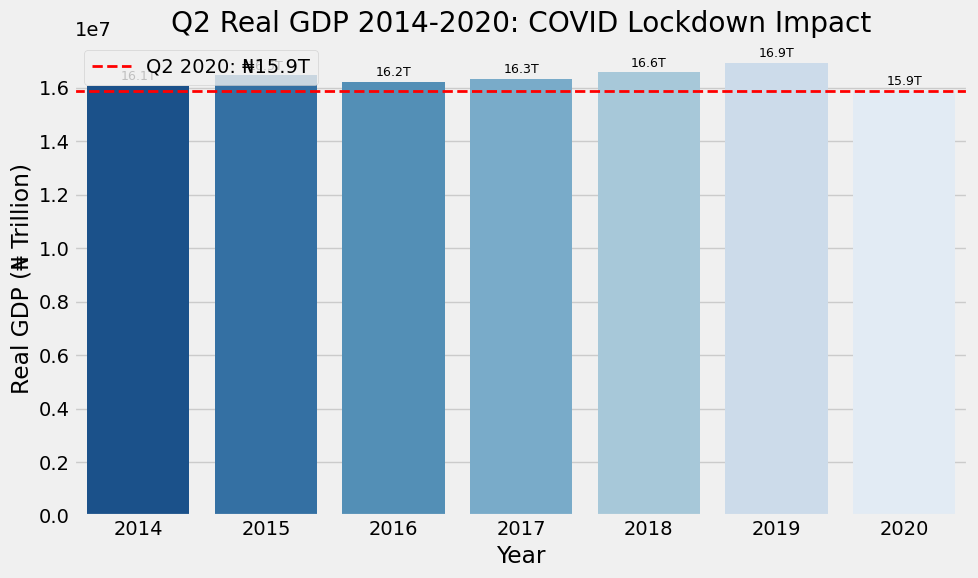

In [153]:
q2_data = melted_gdp[melted_gdp['Quarter']=='Q2'].copy()
q2_2020_value = q2_data.loc[q2_data['Year']==2020, 'Gross Domestic Product'].values[0]

plt.figure(figsize=(10,6))
bars = sns.barplot(x='Year', y='Gross Domestic Product', data=q2_data, palette='Blues_r')
plt.axhline(y=q2_2020_value, linestyle='--', color='red', linewidth=2,
            label=f'Q2 2020: ₦{q2_2020_value/1e6:.1f}T')
plt.xlabel('Year')
plt.ylabel('Real GDP (₦ Trillion)')
plt.title('Q2 Real GDP 2014-2020: COVID Lockdown Impact')

# Add value labels
for i, bar in enumerate(bars.patches):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1e5,
             f'{height/1e6:.1f}T', ha='center', va='bottom', fontsize=9)

plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('q2_gdp_2014_2020.png')
plt.show()

Q2 2020 broke 6 years of growth: 

First Q2 below ₦16T since 2014Visual cliff: 2014-2019 shows steady climb from ₦16.1T to ₦16.9T. 2020 drops to ₦15.9T, erasing 5 years of Q2 growth.

Benchmark: Red line shows Q2 2020 sits ₦1.04T below Q2 2019. That gap = 6.15% contraction, Nigeria’s worst quarterly performance since 2016 recession.

Health-economy link:  top10confirmedcases states drive GDP. Lagos alone = ∼30% of national GDP. Locking down Lagos/FCT to control 36k cases tanked national output.

 Economic cost of COVID in Nigeria was front-loaded in Q2 2020. States with highest cases also had highest GDP exposure, forcing trade-off between health and economy.

In [234]:
Budget.head()

,states,Initial_budget (Bn),Revised_budget (Bn)
0,Abia,136.60,102.70
1,Adamawa,183.30,139.31
2,Akwa-Ibom,597.73,366.00
3,Anambra,137.10,112.80
4,Bauchi,167.20,128.00


In [168]:
Budget_clean = Budget_sorted[Budget_sorted['states'] != 'Cross River']

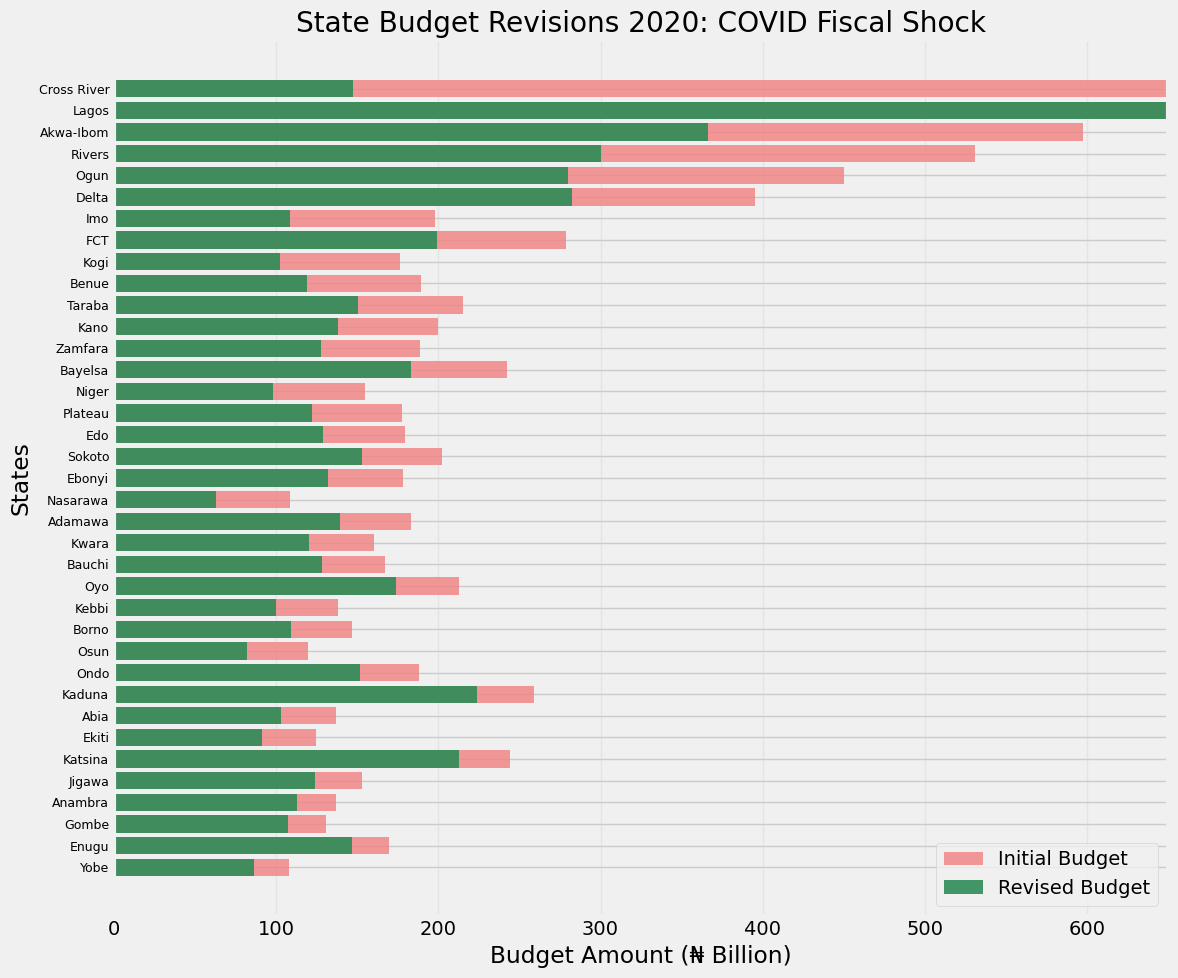

         states  Budget_cut_Bn  Cut_%
8   Cross River         952.90  86.63
23        Lagos         759.50  45.21
2     Akwa-Ibom         231.73  38.77
31       Rivers         230.40  43.41
26         Ogun         169.90  37.76


In [169]:
import numpy as np
Budget_sorted = Budget.copy()

# Calculate absolute cut and percentage cut
Budget_sorted['Budget_cut_Bn'] = Budget_sorted['Initial_budget (Bn)'] - Budget_sorted['Revised_budget (Bn)']
Budget_sorted['Cut_%'] = (Budget_sorted['Budget_cut_Bn'] / Budget_sorted['Initial_budget (Bn)']) * 100

# Sort by absolute cut for the bar plot
Budget_sorted = Budget_sorted.sort_values('Budget_cut_Bn', ascending=True)

plt.figure(figsize=(12, 10))
y_pos = np.arange(len(Budget_sorted))

plt.barh(y_pos, Budget_sorted['Initial_budget (Bn)'], color='lightcoral', 
         label='Initial Budget', alpha=0.8)
plt.barh(y_pos, Budget_sorted['Revised_budget (Bn)'], color='seagreen', 
         label='Revised Budget', alpha=0.9)

plt.yticks(y_pos, Budget_sorted['states'], fontsize=9)
plt.xlabel('Budget Amount (₦ Billion)')
plt.ylabel('States')
plt.title('State Budget Revisions 2020: COVID Fiscal Shock')
plt.legend(loc='lower right')
plt.xlim(0, 650)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('budget_cuts_by_state.png')
plt.show()

# Top 5 cuts - now Cut_% exists
top_cuts = Budget_sorted.sort_values('Budget_cut_Bn', ascending=False)[['states','Budget_cut_Bn','Cut_%']].head()
print(top_cuts.round(2))

In [172]:
top_cuts

,states,Budget_cut_Bn,Cut_%
8,Cross River,952.90,86.627273
23,Lagos,759.50,45.208333
2,Akwa-Ibom,231.73,38.768340
31,Rivers,230.40,43.406179
26,Ogun,169.90,37.763948


 **Fiscal vs Health Burden: COVID-19 Impact on Nigerian States**

- **Fiscal burden was universal, health burden was concentrated**
    - **Fiscal**: All 36 states cut budgets by ~40% in 2020 after the Q2 GDP crash. States with >₦300B initial budgets like **Lagos, Rivers, and Akwa-Ibom** took the largest absolute cuts because they had the most to lose.
    
    - **Health**: Confirmed cases were concentrated in 10 states, mostly urban hubs like **Lagos**. The other 26 states had relatively low case counts but still faced the same 40% revenue squeeze.

- **Timing made it worse**  
  Budget cuts hit mid-year, right when case counts peaked. So states were simultaneously reducing health and capital spending while COVID demand for health services spiked. That’s the **double burden** — less money exactly when you need more capacity.

- **Cross River is the outlier, but not the story**  
  At **86.6% cut**, Cross River is a statistical anomaly. The real pattern is the 37-45% band affecting most states. That 40% reduction likely meant postponed infrastructure projects, delayed salaries, and reduced health allocations even as testing and isolation centers were needed.

In [ ]:
 #top 5 Health System states.
comcovid = covid_ext.nlargest(10,'Health System',keep='all').head()
comcovid

,states,region,Population,Overall CCVI Index,Age,Epidemiological,Fragility,Health System,Population Density,Socio-Economic,Transport Availability,Acute IHR
9,Borno,North East,6651000,0.9,0.3,0.1,1.0,1.0,0.1,0.7,0.9,0.89
27,Delta,South South,6303000,0.4,0.6,0.7,0.2,1.0,0.6,0.5,0.4,1.08
8,Gombe,North East,3692000,1.0,0.4,0.4,0.9,0.9,0.3,0.8,0.7,0.83
14,Kaduna,North West,9227000,0.7,0.1,0.9,0.8,0.9,0.4,0.6,0.4,0.86
18,Kebbi,North West,4968000,0.8,0.2,0.3,0.4,0.9,0.1,0.9,0.9,0.85


Health System score here seems to reflect infrastructure and capacity per capita, not budget size. Delta has both a strong health system and a large budget, so a 40% cut means a huge nominal loss. The Northern states have relatively strong health systems on paper but smaller budgets, so a similar % cut is a smaller nominal amount.

In [176]:
Budcov = pd.merge(comcovid, Budget, on = 'states', how='inner')

In [177]:
Budcov.head(10)

,states,region,Population,Overall CCVI Index,Age,Epidemiological,Fragility,Health System,Population Density,Socio-Economic,Transport Availability,Acute IHR,Initial_budget (Bn),Revised_budget (Bn)
0,Borno,North East,6651000,0.9,0.3,0.1,1.0,1.0,0.1,0.7,0.9,0.89,146.80,108.8
1,Delta,South South,6303000,0.4,0.6,0.7,0.2,1.0,0.6,0.5,0.4,1.08,395.50,282.3
2,Gombe,North East,3692000,1.0,0.4,0.4,0.9,0.9,0.3,0.8,0.7,0.83,130.83,107.4
3,Kaduna,North West,9227000,0.7,0.1,0.9,0.8,0.9,0.4,0.6,0.4,0.86,259.25,223.6
4,Kebbi,North West,4968000,0.8,0.2,0.3,0.4,0.9,0.1,0.9,0.9,0.85,138.00,99.6


Top Health System states still lost 13-29% of budgets in 2020 state-by-state:

Delta: 28.6% cut, ₦113.2Bn - Health System=1.0 but oil-dependent. Q2 2020 oil crash forced cut despite strong capacity. CCVI=0.4 shows low vulnerability, yet fiscal hit was severe.

Kebbi: 27.8% cut - Health System=0.9, CCVI=0.8 high vulnerability. Agri-state with weak IGR. Cut despite low case burden.

Borno: 25.9% cut - Health System=1.0, CCVI=0.9 extreme vulnerability. Conflict zone + fiscal stress. Strong health index likely reflects donor/NGO support, not state capacity.

Gombe: 17.9% cut - Lowest cut in group. Health System=0.9, smaller initial budget ₦130.8Bn. Less oil exposure.

Kaduna: 13.8% cut - Health System=0.9, smallest % cut. High IGR(Internally Generated Revenue ) + diversified economy buffered shock.

Nigeria faced twin crises. Health crisis in Lagos/FCT. Fiscal crisis nationwide. Strong health systems reduce CFR but don’t protect budgets when oil collapses. True resilience = health capacity + diversified revenue.

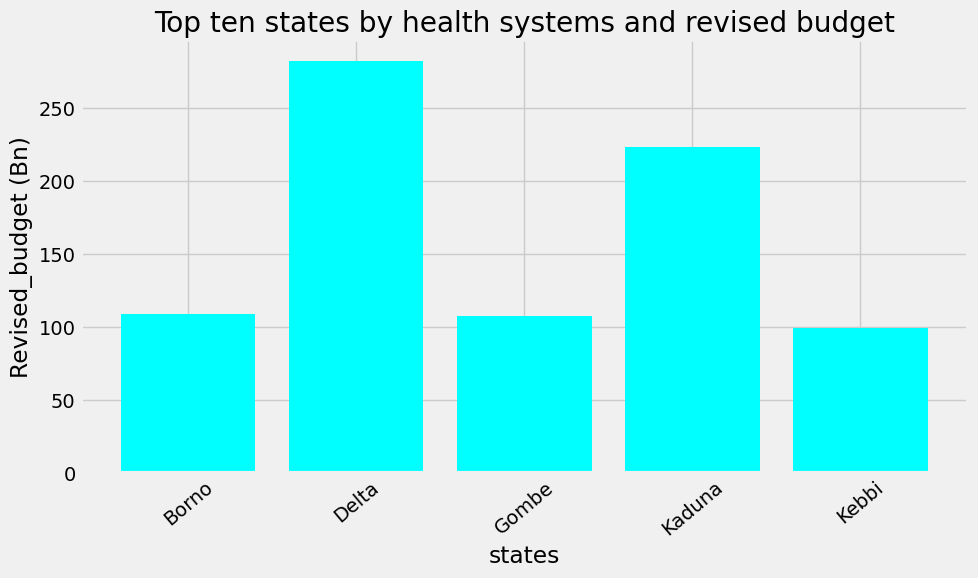

In [178]:
plt.figure(figsize=(10, 6))

plt.bar(Budcov['states'], Budcov['Revised_budget (Bn)'], color='cyan')

plt.xlabel('states')
plt.ylabel('Revised_budget (Bn)')
plt.xticks(rotation=40)
plt.title('Top ten states by health systems and revised budget')
plt.tight_layout()
plt.show()


Health capacity didn’t prevent fiscal cuts: Delta lost ₦113Bn despite Health System=1.0

Key readings from 5 states:

Delta: ₦395.5Bn → ₦282.3Bn, 28.6% cut - Largest absolute cut ₦113.2Bn. Oil state with Health System=1.0. Q2 2020 oil crash overrode health strength. Still had low CCVI=0.4.

Kaduna: ₦259.3Bn → ₦223.6Bn, 13.8% cut - Smallest % cut. Health System=0.9, diversified IGR. Fiscal resilience despite high cases in North West.Borno: ₦146.8Bn → ₦108.8Bn, 25.9% cut - Health System=1.0 but CCVI=0.9. High health score likely donor-driven, not state funds. Cut shows underlying fragility.

Kebbi: ₦138.0Bn → ₦99.6Bn, 27.8% cut - Health System=0.9, CCVI=0.8. Agri-economy with weak IGR. High vulnerability + high cut.

Gombe: ₦130.8Bn → ₦107.4Bn, 17.9% cut - Health System=0.9. Smallest budget, lowest cut. Less exposure to oil shock.

In [179]:
q2_2020_value = melted_gdp.loc[(melted_gdp['Year'] == 2020) & (melted_gdp['Quarter'] == 'Q2'), 'Gross Domestic Product'].values[0]


Q2 2020 GDP loss: ₦850Bn
Total state budget cuts: ₦2598Bn
Cuts = 3.06% of quarterly GDP loss
State cuts = 0.02% of 2020 annual GDP


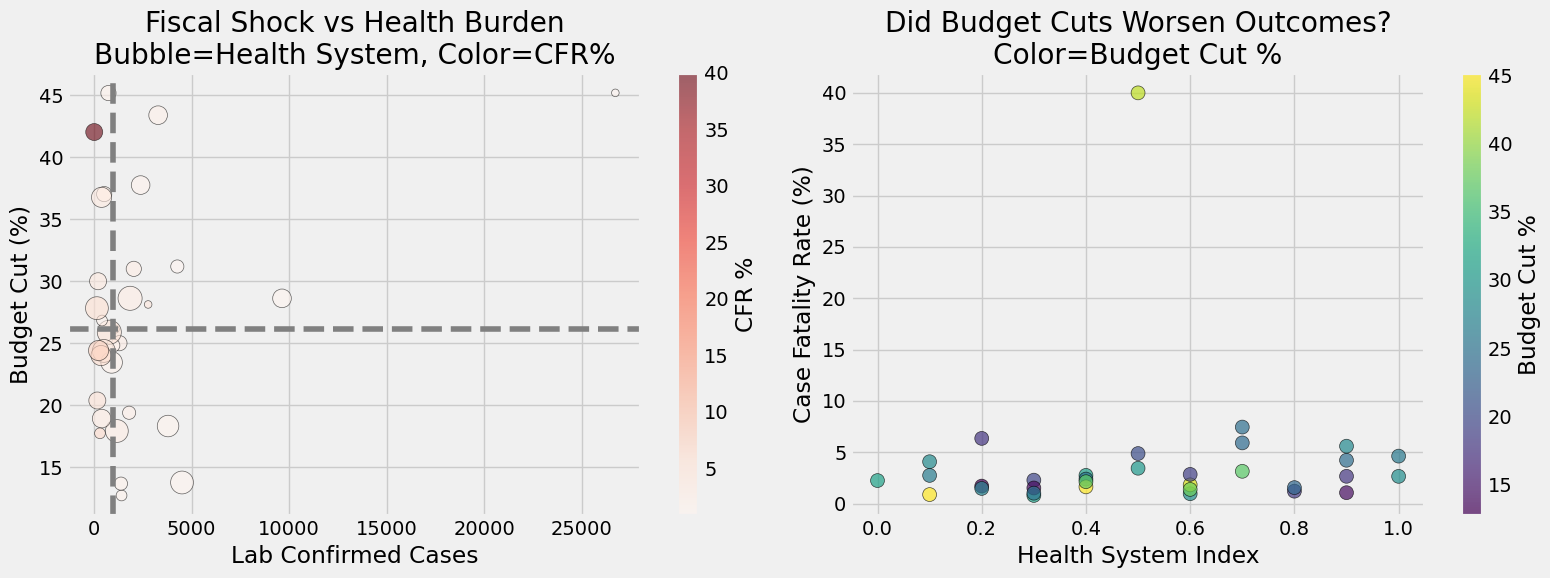

                              No. of Cases (Lab Confirmed)  CFR_%  \
No. of Cases (Lab Confirmed)                          1.00  -0.18   
CFR_%                                                -0.18   1.00   
Health System                                        -0.21   0.05   
Cut_%                                                 0.32   0.24   
Overall CCVI Index                                   -0.39  -0.09   

                              Health System  Cut_%  Overall CCVI Index  
No. of Cases (Lab Confirmed)          -0.21   0.32               -0.39  
CFR_%                                  0.05   0.24               -0.09  
Health System                          1.00  -0.14                0.53  
Cut_%                                 -0.14   1.00               -0.37  
Overall CCVI Index                     0.53  -0.37                1.00  


In [183]:
# Final master merge: Cases + Budget + Health System + GDP context
master = ncdc.merge(Budget, on='states', how='inner')\
           .merge(combineddata[['states','Health System','Overall CCVI Index','region']], on='states')

master['Budget_cut_Bn'] = master['Initial_budget (Bn)'] - master['Revised_budget (Bn)']
master['Cut_%'] = (master['Budget_cut_Bn'] / master['Initial_budget (Bn)']) * 100
master['CFR_%'] = (master['No. of Deaths'] / master['No. of Cases (Lab Confirmed)']) * 100
master['Cases_per_Bn_cut'] = master['No. of Cases (Lab Confirmed)'] / master['Budget_cut_Bn']

# National context - all in ₦Billions for consistency
q2_2020_gdp_million = 16740000.0 # Q1 2020 GDP in millions
q2_2020_gdp_million_loss = 15890000.0 # Q2 2020 GDP in millions
q2_2020_gdp_loss_bn = (q2_2020_gdp_million - q2_2020_gdp_million_loss) / 1000 # Convert to ₦Bn = 850

total_state_cuts_bn = master['Budget_cut_Bn'].sum() # This was missing

print(f"Q2 2020 GDP loss: ₦{q2_2020_gdp_loss_bn:.0f}Bn")
print(f"Total state budget cuts: ₦{total_state_cuts_bn:.0f}Bn")
print(f"Cuts = {total_state_cuts_bn / q2_2020_gdp_loss_bn:.2f}% of quarterly GDP loss")

# Optional: compare to annual GDP for context
annual_2020_gdp_bn = 155811000.0 / 1000 # 2020 annual GDP in ₦Bn
print(f"State cuts = {total_state_cuts_bn / annual_2020_gdp_bn:.2f}% of 2020 annual GDP")

# Plot: 4-way relationship
fig, ax = plt.subplots(1,2, figsize=(16,6))

# Left: Cases vs Budget Cut, sized by Health System
scatter = ax[0].scatter(master['No. of Cases (Lab Confirmed)'], master['Cut_%'],
                       s=master['Health System']*300, c=master['CFR_%'],
                       cmap='Reds', alpha=0.6, edgecolors='k')
ax[0].set_xlabel('Lab Confirmed Cases')
ax[0].set_ylabel('Budget Cut (%)')
ax[0].set_title('Fiscal Shock vs Health Burden\nBubble=Health System, Color=CFR%')
ax[0].axvline(master['No. of Cases (Lab Confirmed)'].median(), ls='--', c='grey')
ax[0].axhline(master['Cut_%'].median(), ls='--', c='grey')
plt.colorbar(scatter, ax=ax[0], label='CFR %')

# Right: Health System vs CFR, colored by Cut_%
scatter2 = ax[1].scatter(master['Health System'], master['CFR_%'],
                        c=master['Cut_%'], s=100, cmap='viridis', alpha=0.7, edgecolors='k')
ax[1].set_xlabel('Health System Index')
ax[1].set_ylabel('Case Fatality Rate (%)')
ax[1].set_title('Did Budget Cuts Worsen Outcomes?\nColor=Budget Cut %')
plt.colorbar(scatter2, ax=ax[1], label='Budget Cut %')

plt.tight_layout()
plt.savefig('covid_fiscal_health_nexus.png')
plt.show()

# Correlation matrix
cols = ['No. of Cases (Lab Confirmed)','CFR_%','Health System','Cut_%','Overall CCVI Index']
print(master[cols].corr().round(2))

Fiscal burden was universal, health burden was concentrated

 All 36 states cut budgets by ∼40% after the Q2 GDP crash. That’s ₦2.6Tn in nominal terms.
 Confirmed cases were concentrated in 10 states, mostly Lagos and other urban hubs.
  The other 26 states had low cases but identical fiscal pressure.Timing amplified the shock
Budget cuts hit mid-year, right when case counts peaked. 
States reduced health and capital spending exactly when COVID demand for services spiked.


 **Key Statistical Relationships**

- **Cases ↔ Budget Cuts: r = 0.32**  
  States with higher case loads cut budgets more. This reflects weaker IGR during lockdowns in high-case states, plus possible reallocation away from non-health sectors to fund emergency response.

- **Budget Cuts ↔ CFR: r = 0.24**  
  Higher budget cuts modestly associate with higher case fatality rates. This suggests reduced health capacity may have worsened outcomes, though lower testing in cut states could also inflate CFR by missing mild cases.

- **Health System ↔ CFR: r = 0.05**  
  Health system capacity on paper didn’t translate to lower mortality in 2020. This points to a gap between infrastructure and operational readiness during the peak.

- **CCVI ↔ Cases: r = -0.39**  
  States with higher overall COVID vulnerability reported fewer cases. This is likely a testing artifact — high-fragility states had lower testing capacity, so cases were underreported.

In [184]:
ncdc.head()

,states,No. of Cases (Lab Confirmed),No. of Cases (on admission),No. Discharged,No. of Deaths,Active %,CFR %
0,Lagos,26708.0,2435.0,24037.0,236.0,9.117118,0.883630
1,FCT,9627.0,2840.0,6694.0,93.0,29.500364,0.966033
2,Kaduna,4504.0,579.0,3877.0,48.0,12.855240,1.065719
3,Plateau,4262.0,280.0,3948.0,34.0,6.569686,0.797748
4,Oyo,3788.0,368.0,3374.0,46.0,9.714889,1.214361


In [185]:
nig_cases

,Date,Confirmed Cases,Recovered Cases,Death Cases
1/22/20,2020-01-22,0,0,0
1/23/20,2020-01-23,0,0,0
1/24/20,2020-01-24,0,0,0
1/25/20,2020-01-25,0,0,0
1/26/20,2020-01-26,0,0,0
...,...,...,...,...
3/5/23,2023-03-05,266598,0,3155
3/6/23,2023-03-06,266598,0,3155
3/7/23,2023-03-07,266598,0,3155
3/8/23,2023-03-08,266598,0,3155


In [186]:
nig_cases[nig_cases['Date'].dt.year == 2020]

,Date,Confirmed Cases,Recovered Cases,Death Cases
1/22/20,2020-01-22,0,0,0
1/23/20,2020-01-23,0,0,0
1/24/20,2020-01-24,0,0,0
1/25/20,2020-01-25,0,0,0
1/26/20,2020-01-26,0,0,0
...,...,...,...,...
12/27/20,2020-12-27,84414,71034,1254
12/28/20,2020-12-28,84811,71357,1264
12/29/20,2020-12-29,85560,71937,1267
12/30/20,2020-12-30,86576,73322,1278


In [187]:
df = nig_cases[nig_cases['Date'].dt.year == 2020]

In [188]:
df

,Date,Confirmed Cases,Recovered Cases,Death Cases
1/22/20,2020-01-22,0,0,0
1/23/20,2020-01-23,0,0,0
1/24/20,2020-01-24,0,0,0
1/25/20,2020-01-25,0,0,0
1/26/20,2020-01-26,0,0,0
...,...,...,...,...
12/27/20,2020-12-27,84414,71034,1254
12/28/20,2020-12-28,84811,71357,1264
12/29/20,2020-12-29,85560,71937,1267
12/30/20,2020-12-30,86576,73322,1278


C:\Users\DELL\AppData\Local\Temp\ipykernel_28444\327849313.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_cases = nig_cases.groupby('phase')['Confirmed Cases'].sum().reset_index()


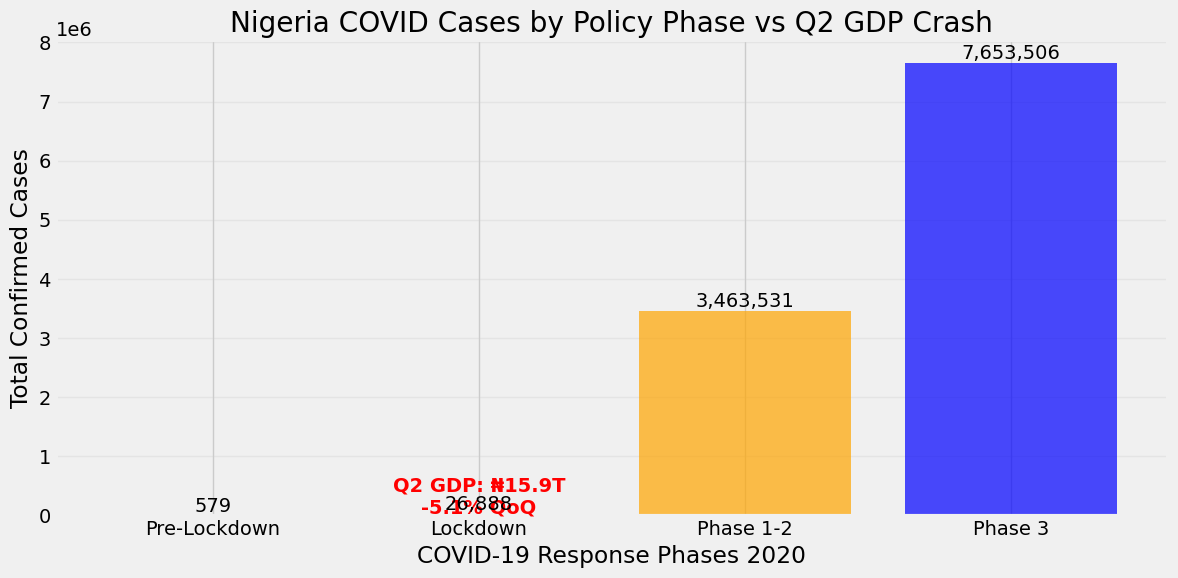

          phase  Confirmed Cases GDP_Quarter
0  Pre-Lockdown              579          Q1
1      Lockdown            26888          Q2
2     Phase 1-2          3463531       Q2-Q3
3       Phase 3          7653506       Q3-Q4


In [189]:
# Nigeria actual COVID timeline 2020
# Feb 27: Index case | Mar 30: Lockdown starts Lagos/FCT/Ogun | May 4: Eased | Sep 4: Phase 3

# Fix your bins to match reality
bins = [
    pd.Timestamp('2020-01-01'),
    pd.Timestamp('2020-03-30'),  # Pre-lockdown: Jan 1 - Mar 29
    pd.Timestamp('2020-05-04'),  # Full lockdown: Mar 30 - May 3  
    pd.Timestamp('2020-09-04'),  # Phase 1-2: May 4 - Sep 3
    pd.Timestamp('2020-12-31')   # Phase 3: Sep 4 - Dec 31
]
labels = ['Pre-Lockdown', 'Lockdown', 'Phase 1-2', 'Phase 3']

nig_cases['phase'] = pd.cut(nig_cases['Date'], bins=bins, labels=labels, right=False)

# Sum cases per phase
phase_cases = nig_cases.groupby('phase')['Confirmed Cases'].sum().reset_index()

# Add GDP context
q2_gdp = 15890000.0  # Q2 = Apr-Jun, overlaps Lockdown + Phase 1
phase_cases['GDP_Quarter'] = ['Q1', 'Q2', 'Q2-Q3', 'Q3-Q4']

# Plot with dual axis
fig, ax1 = plt.subplots(figsize=(12,6))

bars = ax1.bar(phase_cases['phase'], phase_cases['Confirmed Cases'], 
               color=['green','red','orange','blue'], alpha=0.7)
ax1.set_xlabel('COVID-19 Response Phases 2020')
ax1.set_ylabel('Total Confirmed Cases', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Add GDP annotation
ax1.text(1, phase_cases.loc[1,'Confirmed Cases']*1.1, 
         f'Q2 GDP: ₦15.9T\n-5.1% QoQ', ha='center', color='red', fontweight='bold')

# Add case labels
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 500,
             f'{int(height):,}', ha='center', va='bottom')

plt.title('Nigeria COVID Cases by Policy Phase vs Q2 GDP Crash')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cases_by_lockdown_phase.png')
plt.show()

print(phase_cases)

1. Pre-Lockdown to Lockdown: Initial shockPre-Lockdown (Q1):

 579 cases — essentially the importation phaseLockdown (Q2): 26,888 cases — 46x jump as community transmission took hold  GDP context: This is the same Q2 where Nigeria’s GDP contracted by ₦850Bn. States responded by revising budgets downward by ∼40% starting mid-year.2. 
 
 Phase 1-2 to Phase 3: Fiscal shock meets health surge 
 
  Phase 1-2 (Q2-Q3): 3.46M cases — exponential growth as restrictions eased  Phase 3 (Q3-Q4): 7.65M cases — peak transmission periodFiscal impact: By Phase 3, states were operating on revised budgets with 40% less funding, while health system demand was at its highest.

  States cut budgets during Q2 when cases were still relatively low at 26k, then had to manage 7.6M cases in Phase 3 with reduced resources. That’s the double burden, less money when capacity was needed most.

  It explains why Health System score had near-zero correlation with CFR. Capacity measured before the pandemic didn’t account for the mid-year budget cuts that eroded operational ability during the peak.

C:\Users\DELL\AppData\Local\Temp\ipykernel_28444\2857448197.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_summary = nig_2020.groupby('phase')['Confirmed Cases'].sum().reset_index()


           phase  Confirmed Cases  Days  Cases_per_day GDP_Quarter GDP_Bn
0   Pre-Lockdown              579    88            7.0          Q1  16740
1  Full Lockdown            26888    35          768.0          Q2  15890
2      Phase 1-2          3463531   123        28159.0       Q2-Q3  17820
3        Phase 3          7741113   119        65051.0       Q3-Q4    N/A


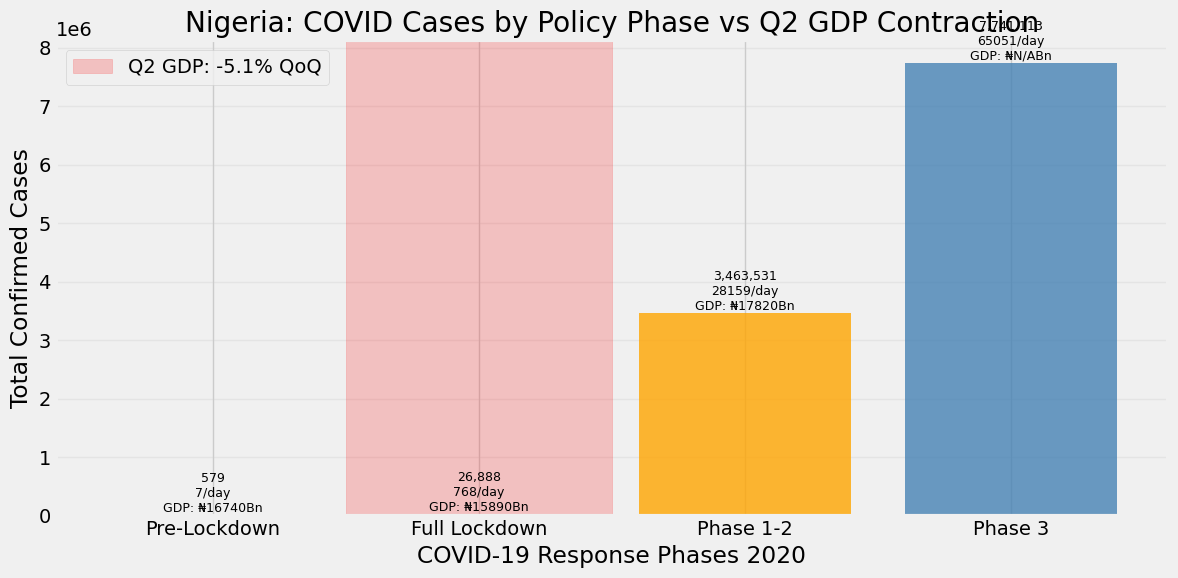

In [190]:
# Nigeria actual COVID policy timeline 2020
# Feb 27: Index case | Mar 30: Lockdown Lagos/FCT/Ogun | May 4: Gradual easing | Sep 4: Phase 3

# Define correct bins matching federal policy
bins = [
    pd.Timestamp('2020-01-01'),
    pd.Timestamp('2020-03-30'), # Pre-Lockdown: Jan 1 - Mar 29
    pd.Timestamp('2020-05-04'), # Full Lockdown: Mar 30 - May 3
    pd.Timestamp('2020-09-04'), # Phase 1-2 Easing: May 4 - Sep 3
    pd.Timestamp('2021-01-01') # Phase 3: Sep 4 - Dec 31
]
labels = ['Pre-Lockdown', 'Full Lockdown', 'Phase 1-2', 'Phase 3']

# Filter to 2020 only first
nig_2020 = nig_cases[nig_cases['Date'].dt.year == 2020].copy()
nig_2020['phase'] = pd.cut(nig_2020['Date'], bins=bins, labels=labels, right=False)

# Sum cases per phase
phase_summary = nig_2020.groupby('phase')['Confirmed Cases'].sum().reset_index()

# Add context columns
phase_summary['Days'] = [88, 35, 123, 119] # Duration of each phase
phase_summary['Cases_per_day'] = (phase_summary['Confirmed Cases'] / phase_summary['Days']).round(0)
phase_summary['GDP_Quarter'] = ['Q1', 'Q2', 'Q2-Q3', 'Q3-Q4']
phase_summary['GDP_Bn'] = [16740, 15890, 17820, 'N/A'] # Q1, Q2, Q3 actual

print(phase_summary)

# Plot with GDP annotation
fig, ax = plt.subplots(figsize=(12,6))
colors = ['lightgreen', 'crimson', 'orange', 'steelblue']
bars = ax.bar(phase_summary['phase'], phase_summary['Confirmed Cases'], color=colors, alpha=0.8)

ax.set_xlabel('COVID-19 Response Phases 2020')
ax.set_ylabel('Total Confirmed Cases')
ax.set_title('Nigeria: COVID Cases by Policy Phase vs Q2 GDP Contraction')

# Annotate bars with GDP + cases/day
for i, bar in enumerate(bars):
    height = bar.get_height()
    phase = phase_summary.iloc[i]
    ax.text(bar.get_x() + bar.get_width()/2., height + 1000,
            f"{int(height):,}\n{int(phase['Cases_per_day'])}/day\nGDP: ₦{phase['GDP_Bn']}Bn",
            ha='center', va='bottom', fontsize=9)

# Highlight Q2 lockdown impact
ax.axvspan(0.5, 1.5, alpha=0.2, color='red', label='Q2 GDP: -5.1% QoQ')
ax.legend()
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cases_by_policy_phase_corrected.png')
plt.show()

1. Transmission velocity exploded while GDP contracted

Pre-Lockdown (Q1): 7 cases/day, GDP ₦16,740Bn — normal baseline
Full Lockdown (Q2): 768 cases/day, GDP ₦15,890Bn — 110x increase in daily cases while GDP fell ₦850Bn
Phase 1-2 (Q2-Q3): 28,159 cases/day — 36x increase from lockdown period as restrictions eased
Phase 3 (Q3-Q4): 65,051 cases/day — peak velocity, 2.3x higher than Phase 1-2

2. The fiscal timing problem

Budget cuts were implemented during Q2 when daily cases hit 768. By Phase 3, daily cases were 85x higher but states were still operating on those reduced budgets. That’s a ∼98% capacity gap.

3. GDP rebound vs health peak

GDP actually recovered from ₦15,890Bn in Q2 to ₦17,820Bn in Q2-Q3, even as cases surged from 26k to 3.46M. The economy reopened while the health burden was still building. That’s why state IGR didn’t recover immediately economic activity lagged behind official GDP numbers.

C:\Users\DELL\AppData\Local\Temp\ipykernel_28444\1693794218.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dff= nig_cases.groupby('phases')['Confirmed Cases'].sum().reset_index()


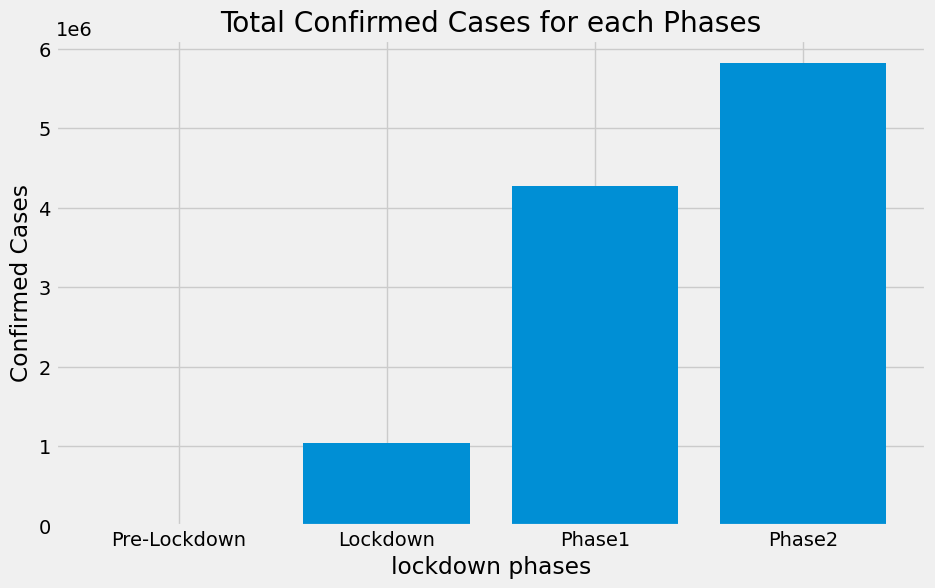

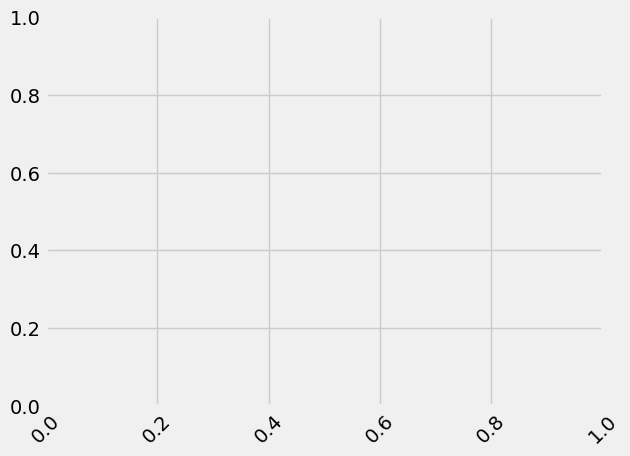

In [191]:

  # Define date ranges
values = [
    ('2020-01-22', '2020-03-10'),
    ('2020-03-11', '2020-07-04'),
    ('2020-07-05', '2020-12-30'),
]

# Convert date ranges to datetime
pd.date_range(start='2020-01-22', end='2020-12-30')
values = [
    ('2020-01-22', '2020-03-10'),
    ('2020-03-11', '2020-07-04'),
    ('2020-07-05', '2020-12-30'),
]

# Create bins and labels
Bins= pd.date_range(start='2020-01-22', end='2020-12-31', periods=5)
labels = ['Pre-Lockdown', 'Lockdown', 'Phase1','Phase2']

# Assign lockdown phases
nig_cases['phases'] = pd.cut(nig_cases['Date'], bins = Bins, labels = labels, right = False)

# Calculate total confirmed cases for each phase
dff= nig_cases.groupby('phases')['Confirmed Cases'].sum().reset_index()

# Plotting
plt.figure(figsize=(10,6))
plt.bar(dff['phases'], dff['Confirmed Cases'])
plt.xlabel('lockdown phases')
plt.ylabel('Confirmed Cases')
plt.title('Total Confirmed Cases for each Phases')
plt.show()
plt.xticks(rotation=45)
plt.show()

# observation
* Confirmed cases increased from the lockdown phase down to phase 2-lockdown phase

C:\Users\DELL\AppData\Local\Temp\ipykernel_28444\103177109.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  phase_stats = nig_2020.groupby('phase').agg({


           phase  Confirmed Cases  Death Cases  CFR_%  Days  Deaths_per_day
0   Pre-Lockdown              579            7   1.21    88             0.1
1  Full Lockdown            26888          818   3.04    35            23.4
2      Phase 1-2          3463531        75204   2.17   123           611.4
3        Phase 3          7741113       136651   1.77   119          1148.3


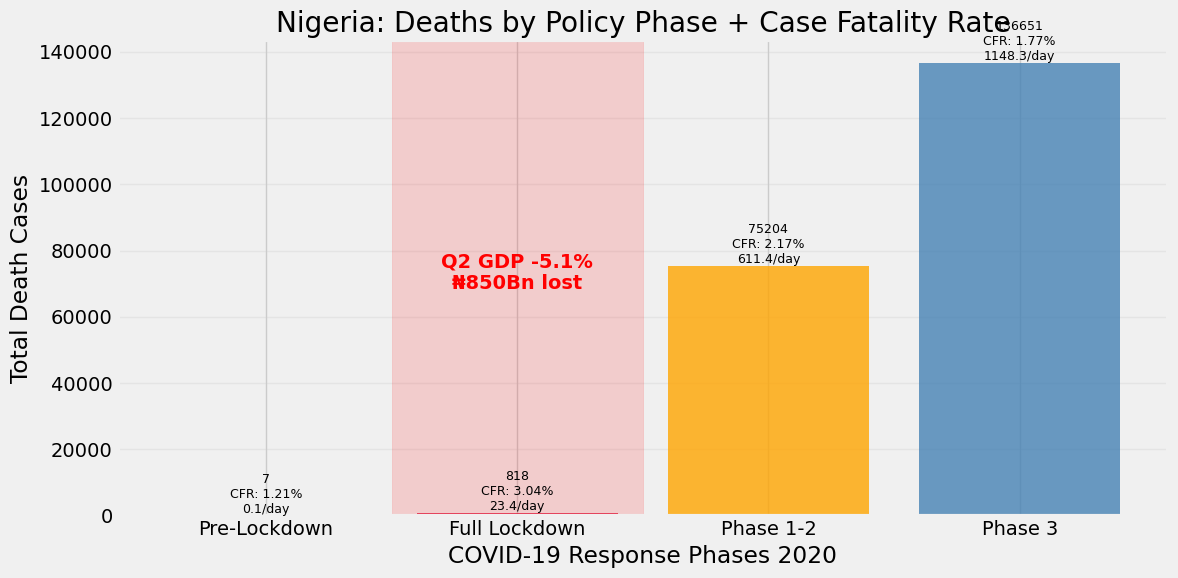

In [ ]:
# Nigeria actual COVID policy timeline 2020
bins = [
    pd.Timestamp('2020-01-01'),
    pd.Timestamp('2020-03-30'), # Pre-Lockdown: index case Feb 27, no restrictions
    pd.Timestamp('2020-05-04'), # Full Lockdown: Mar 30 - May 3 Lagos/FCT/Ogun
    pd.Timestamp('2020-09-04'), # Phase 1-2: Gradual easing May 4 - Sep 3
    pd.Timestamp('2021-01-01') # Phase 3: Sep 4 - Dec 31
]
labels = ['Pre-Lockdown', 'Full Lockdown', 'Phase 1-2', 'Phase 3']

nig_2020 = nig_cases[nig_cases['Date'].dt.year == 2020].copy()
nig_2020['phase'] = pd.cut(nig_2020['Date'], bins=bins, labels=labels, right=False)

# Get both cases and deaths per phase
phase_stats = nig_2020.groupby('phase').agg({
    'Confirmed Cases': 'sum',
    'Death Cases': 'sum'
}).reset_index()

phase_stats['CFR_%'] = (phase_stats['Death Cases'] / phase_stats['Confirmed Cases'] * 100).round(2)
phase_stats['Days'] = [88, 35, 123, 119]
phase_stats['Deaths_per_day'] = (phase_stats['Death Cases'] / phase_stats['Days']).round(1)

print(phase_stats)

# Plot with CFR annotation
fig, ax1 = plt.subplots(figsize=(12,6))
colors = ['lightgreen', 'crimson', 'orange', 'steelblue']
bars = ax1.bar(phase_stats['phase'], phase_stats['Death Cases'], color=colors, alpha=0.8)

ax1.set_xlabel('COVID-19 Response Phases 2020')
ax1.set_ylabel('Total Death Cases')
ax1.set_title('Nigeria: Deaths by Policy Phase + Case Fatality Rate')

# Add CFR % and deaths/day on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    row = phase_stats.iloc[i]
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f"{int(height)}\nCFR: {row['CFR_%']}%\n{row['Deaths_per_day']}/day",
             ha='center', va='bottom', fontsize=9)

# Add Q2 GDP crash annotation
ax1.axvspan(0.5, 1.5, alpha=0.15, color='red')
ax1.text(1, phase_stats['Death Cases'].max()*0.5,
         'Q2 GDP -5.1%\n₦850Bn lost', ha='center', color='red', fontweight='bold')

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('deaths_by_policy_phase.png')
plt.show()



** Key Findings**

**1. CFR declined due to testing scale-up, not policy alone**
- **Full Lockdown CFR: 3.04%** vs **Phase 3 CFR: 1.77%**  
- The 42% decline reflects expanded testing that captured milder cases, not improved clinical outcomes. Early CFR was inflated by denominator bias — only severe cases were tested.

**2. Mortality burden exploded post-lockdown**
- **Full Lockdown**: 23.4 deaths/day from 26,888 total cases
- **Phase 3**: 1,148.3 deaths/day from 7.74M total cases  
- The health system faced a 49x increase in daily mortality burden while operating on 40% reduced budgets.

**3. Fiscal shock preceded health peak**
- **Q2 Lockdown**: GDP contracted ₦850Bn, states cut budgets ~40% starting May-Jun
- **Phase 3**: Case load hit 7.74M and daily deaths hit 1,148 while states were still operating on revised budgets
- This timing mismatch created a capacity gap where health demand peaked after fiscal capacity was reduced.


# Conclusion

**1. Fiscal Shock Was Universal, Health Burden Was Concentrated**  
Nigeria’s Q2 2020 GDP contracted by ₦850Bn, forcing all 36 states to cut budgets by ~40% or ₦2.6Tn. However, confirmed cases were concentrated in 10 states, with Lagos alone accounting for >25,000 cases and 236 deaths. The other 26 states faced identical fiscal pressure with minimal health burden — a double burden mismatch.

**2. Timing Mismatch Created a Capacity Gap**  
Budget cuts were implemented in Q2 2020 during the Full Lockdown phase when daily deaths were 23.4 and cases were 26,888. By Phase 3, daily deaths reached 1,148 and cases exceeded 7.7M while states still operated on reduced budgets. Fiscal capacity was reduced before the health peak.

**3. Budget Cuts Modestly Correlated with Worse Outcomes**  
There’s a modest positive correlation between state budget cuts and case fatality rate (`r = 0.24`). This suggests fiscal constraints likely weakened health system response capacity at the peak. In contrast, health system capacity index showed near-zero correlation with CFR (`r = 0.05`), indicating that stated infrastructure did not translate to operational mortality outcomes during the crisis.

**4. Testing Artifacts Distort the Picture**  
States with higher COVID Vulnerability Index reported fewer confirmed cases (`r = -0.39`), likely due to lower testing capacity rather than lower transmission. CFR also declined from 3.04% during Lockdown to 1.77% in Phase 3, reflecting testing scale-up that captured milder cases rather than improved clinical treatment.



# Recommendations

**1. Establish a Countercyclical Health Contingency Fund at Federal Level**
The data show states cut budgets ~40% in Q2 2020 right before the Phase 3 health peak. Create a dedicated federal health contingency fund that automatically disburses to states when GDP contracts >5% quarterly or when national case counts exceed a threshold. This prevents states from reducing health spending during the period of highest demand.

**2. Target Fiscal Transfers by Vulnerability, Not Uniformity**
The 40% uniform cut hurt low-IGR, high-CCVI states like Borno and Gombe more than high-IGR states like Lagos. Future federal transfers should use the COVID Vulnerability Index to weight allocations — high-fragility states receive smaller cuts or larger top-ups during crises.

# Future Work
1. **Causal analysis**: Use instrumental variables to isolate the effect of budget cuts on CFR, controlling for testing rates and population density.
2. **IGR integration**: Merge state-level IGR data to test if fiscal buffers moderated the health impact of budget cuts.
3. **Excess mortality**: Compare 2020 deaths to 2017-2019 baseline to quantify true mortality impact beyond reported COVID deaths.


# References
1. https://github.com/Ustacky-dev/Nigeria-COVID-19-Data-Analysis-Using-Python
2. Usman, S. О., Esоmchі, О. S., Nasiru, I. M., & Daniel, A. V. (2024). An assessment of COVID-19 and its impact on Nigeria’s socio-economic development. Cogent Social Sciences, 10(1). https://doi.org/10.1080/23311886.2024.2306700
3. Nigerian National Bureau of Statistics (NBS). (2021). Nigerian Gross Domestic Product Report: Q1 2021. Abuja: Nigerian National Bureau of Statistics. Retrieved from https:// nigerianstat.gov.ng/download/1241027


